In [8]:
import torch
from pathlib import Path
import sys

# 루트 경로 추가 (Model, dataset 로딩 위해)
root_dir = Path('/storage/personal/eungyeop/LLM/tabular/ProtoLLM')
sys.path.append(str(root_dir))

from models.TabularFLM_S import Model
from dataset.data_dataloaders import prepare_embedding_dataloaders
from utils.util import fix_seed

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4/Pre/ngraphs-8_nnodes-8_gdim-128_nheads-1_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_kl_gamma-0.2_vq_beta-0.3_target_data-heart_description-None/42/best_20251119_141941.pt"

# checkpoint load
ckpt = torch.load(ckpt_path, map_location=device)
args = ckpt['args']

# 모델 초기화
model = Model(
    args,
    args.input_dim,
    args.hidden_dim,
    args.output_dim,
    args.dropout_rate,
    args.llm_model,
    experiment_id="viz",
    mode="viz"
).to(device)

sd = ckpt['model_state_dict']
missing, unexpected = model.load_state_dict(sd, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.eval()


/home/eungyeop/anaconda3/envs/protollm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Missing keys: ['latent_graph.node_embeddings', 'gnn_experts.graph_gnns.0.linear.weight', 'gnn_experts.graph_gnns.0.linear.bias', 'gnn_experts.graph_gnns.0.update.weight', 'gnn_experts.graph_gnns.0.update.bias', 'gnn_experts.graph_gnns.0.norm.weight', 'gnn_experts.graph_gnns.0.norm.bias', 'gnn_experts.graph_gnns.1.linear.weight', 'gnn_experts.graph_gnns.1.linear.bias', 'gnn_experts.graph_gnns.1.update.weight', 'gnn_experts.graph_gnns.1.update.bias', 'gnn_experts.graph_gnns.1.norm.weight', 'gnn_experts.graph_gnns.1.norm.bias', 'gnn_experts.graph_gnns.2.linear.weight', 'gnn_experts.graph_gnns.2.linear.bias', 'gnn_experts.graph_gnns.2.update.weight', 'gnn_experts.graph_gnns.2.update.bias', 'gnn_experts.graph_gnns.2.norm.weight', 'gnn_experts.graph_gnns.2.norm.bias', 'gnn_experts.graph_gnns.3.linear.weight', 'gnn_experts.graph_gnns.3.linear.bias', 'gnn_experts.graph_gnns.3.update.weight', 'gnn_experts.graph_gnns.3.update.bias', 'gnn_experts.graph_gnns.3.norm.weight', 'gnn_experts.graph_gnns

Model(
  (latent_graph): LatentCompositeGraph()
  (graph_quantizer): GraphQuantizer()
  (gnn_experts): LatentCompositeGNN(
    (graph_gnns): ModuleList(
      (0-7): 8 x lightGraphNeuralNet(
        (dropout): Dropout(p=0.1, inplace=False)
        (linear): Linear(in_features=768, out_features=192, bias=True)
        (update): Linear(in_features=192, out_features=768, bias=True)
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
    (readouts): ModuleList(
      (0-7): 8 x GraphReadout(
        (proj): Sequential(
          (0): Linear(in_features=768, out_features=192, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=192, out_features=768, bias=True)
        )
        (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (basis_layers): ModuleList(
    (0-1): 2 x BasisGATLayer_IND(
      (attn_dropout): Dropout(p=0.1, inplace=False)
      (q_proj_list): ModuleLis

In [46]:
args2 = args
fix_seed(args2.random_seed)

# source_data가 리스트일 경우 여러 개
sources = args2.source_data if isinstance(args2.source_data, (list, tuple)) else [args2.source_data]

loaders = {}
for src in sources:
    print(f"Loading dataloader for source: {src}")
    res = prepare_embedding_dataloaders(args2, src)
    tr, va, te = res['loaders']
    
    from torch.utils.data import ConcatDataset, DataLoader
    ds = ConcatDataset([tr.dataset, va.dataset, te.dataset])
    
    loaders[src] = DataLoader(ds, batch_size=32, shuffle=False)


Loading dataloader for source: Heart_disease_statlog
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Heart_disease_statlog.pkl
Training data size: 162
Validation data size: 54
Test data size: 54
Loading dataloader for source: Cardiovascular_Disease_Dataset
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_Cardiovascular_Disease_Dataset.pkl
Training data size: 600
Validation data size: 200
Test data size: 200
Loading dataloader for source: heart_target_3
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart_target_3.pkl
Training data size: 600
Validation data size: 200
Test data size: 200
Loading dataloader for source: heart_target_4
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart_target_4.pkl
Training data size: 600
Va

In [47]:
import torch.nn.functional as F

@torch.no_grad()
def extract_basis_attention_and_embedding(model, batch):
    batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

    # desc/name/value gather
    desc_embeddings, name_embeddings, value_embeddings = [], [], []
    if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
        desc_embeddings.append(batch['cat_desc_embeddings'])
        name_embeddings.append(batch['cat_name_embeddings'])
        value_embeddings.append(batch['cat_value_embeddings'])
    if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
        desc_embeddings.append(batch['num_desc_embeddings'])
        name_embeddings.append(batch['num_name_embeddings'])
        value_embeddings.append(batch['num_prompt_embeddings'])

    desc = torch.cat(desc_embeddings, dim=1)
    name = torch.cat(name_embeddings, dim=1)
    value = torch.cat(value_embeddings, dim=1)

    # CLS + value token concat
    x_basis = torch.cat([model.basis_cls.expand(value.size(0), 1, model.input_dim), value], dim=1)

    attentions = []

    # each BasisGAT layer
    for l in range(model.num_basis_layers):
        norm_x = model.basis_layer_norms[l](x_basis)
        basis_outputs, att = model.basis_layers[l](name, norm_x)
        
        # attention shape: [B, H, T, T]
        attentions.append(att[0].detach().cpu().numpy())
        
        x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

    embeddings = x_basis[0].detach().cpu().numpy()  # CLS+tokens, shape [T, D]
    return attentions, embeddings


In [48]:
import matplotlib.pyplot as plt
import numpy as np

def plot_attention_heatmap(att, feature_names, title):
    H, T, _ = att.shape
    # ---- Bigger, readable figure ----
    figsize_x = max(8, T * 0.8)  # at least width 8
    figsize_y = max(4, H * 3)    # at least height 4

    plt.figure(figsize=(figsize_x, figsize_y))

    for h in range(H):
        plt.subplot(1, H, h+1)
        plt.imshow(att[h], cmap='viridis')

        plt.xticks(range(T), feature_names, rotation=90, fontsize=10)
        plt.yticks(range(T), feature_names, fontsize=10)

        plt.title(f"{title} - Head {h}", fontsize=14)
        plt.colorbar()

    plt.tight_layout()
    plt.show()
from sklearn.manifold import TSNE

def plot_embedding_tsne(emb):
    # emb: [T, D]
    tsne = TSNE(n_components=2, perplexity=10, learning_rate=100)
    xy = tsne.fit_transform(emb)

    plt.figure(figsize=(6, 6))
    plt.scatter(xy[:, 0], xy[:, 1])
    for i in range(xy.shape[0]):
        plt.text(xy[i,0], xy[i,1], str(i), fontsize=8)
    plt.title("t-SNE of embeddings (CLS + features)")
    plt.show()

# ---- viz utilities ----
def set_attention_save_dir( experiment_id, mode):
    base_viz_dir = f"/storage/personal/eungyeop/experiments/visualization/{args.llm_model}/{args.source_data}/{mode}/{experiment_id}"
    attention_save_dir = os.path.join(base_viz_dir, 'attention_maps')
    os.makedirs(attention_save_dir, exist_ok=True)

def extract_feature_names( batch):
    names = []
    if 'cat_desc_texts' in batch:
        for t in batch['cat_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    if 'num_desc_texts' in batch:
        for t in batch['num_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    uniq = []
    seen = set()
    for n in names:
        if n not in seen:
            seen.add(n); uniq.append(n)
    return uniq

def save_attention_maps_to_file( attention_weights, batch, labels=None, sample_ids=None):
    if attention_save_dir is None:
        return
    node_names = ["CLS"] + extract_feature_names(batch)
    for layer_idx, layer_attention in enumerate(attention_weights):
        B = layer_attention.shape[0]
        for b in range(B):
            att = layer_attention[b].mean(dim=0).detach().cpu().numpy()
            sid = sample_ids[b] if sample_ids is not None else attention_counter
            lab = labels[b].item() if labels is not None else "unknown"
            np.savez(os.path.join(attention_save_dir, f"layer_{layer_idx}_sample_{sid}_label_{lab}.npz"),
                        attention_map=att, feature_names=np.array(node_names),
                        layer_idx=layer_idx, sample_id=sid, label=lab)
            attention_counter += 1

import numpy as np

def summarize_embedding_stats(emb, feature_names):
    """
    emb: numpy array [T, D]
    feature_names: list of T names ("CLS" + variable names)
    """
    T, D = emb.shape
    
    print("=== Embedding statistics per token (CLS + features) ===")
    stats = {}
    
    for i in range(T):
        vec = emb[i]
        mean = vec.mean()
        std = vec.std()
        
        stats[feature_names[i]] = {
            'mean': float(mean),
            'std': float(std)
        }
        print(f"{feature_names[i]:>15}  | mean={mean:.4f} | std={std:.4f}")
    
    # 전체 embedding 분포 요약
    print("\n=== Global embedding statistics ===")
    print(f"global mean: {emb.mean():.4f}")
    print(f"global std : {emb.std():.4f}")
    
    return stats

import matplotlib.pyplot as plt
import numpy as np

def plot_attention_with_inverse(
    att,
    feature_names,
    title="Attention",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0,
):
    H, T, _ = att.shape

    figsize_x = max(10, T * 0.7) * figsize_scale
    figsize_y = max(5, H * 3) * figsize_scale

    fig, axes = plt.subplots(H, 2, figsize=(figsize_x, figsize_y))
    if H == 1:
        axes = np.expand_dims(axes, 0)

    cmap = "viridis"

    for h in range(H):
        # ---- LEFT: Attention ----
        left_vmin = att[h].min()
        left_vmax = att[h].max()

        ax = axes[h, 0]
        im = ax.imshow(att[h], cmap=cmap, vmin=left_vmin, vmax=left_vmax)
        ax.set_title(f"{title} - Head {h}", fontsize=title_fontsize)

        ax.set_xticks(range(T))
        ax.set_yticks(range(T))
        ax.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax.text(j, i, f"{att[h, i, j]:.2f}",
                        ha="center", va="center",
                        fontsize=value_fontsize,
                        color="white" if att[h, i, j] > (left_vmin+left_vmax)/2 else "black")

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

        # ---- RIGHT: (1 - Attention) ----
        inv = 1 - att[h]
        right_vmin = inv.min()
        right_vmax = inv.max()

        ax2 = axes[h, 1]
        im2 = ax2.imshow(inv, cmap=cmap, vmin=right_vmin, vmax=right_vmax)
        ax2.set_title(f"(1 - Attention) - Head {h}", fontsize=title_fontsize)

        ax2.set_xticks(range(T))
        ax2.set_yticks(range(T))
        ax2.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax2.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax2.text(j, i, f"{inv[i, j]:.2f}",
                         ha="center", va="center",
                         fontsize=value_fontsize,
                         color="white" if inv[i, j] > (right_vmin+right_vmax)/2 else "black")

        fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.02)

    plt.tight_layout()
    plt.show()





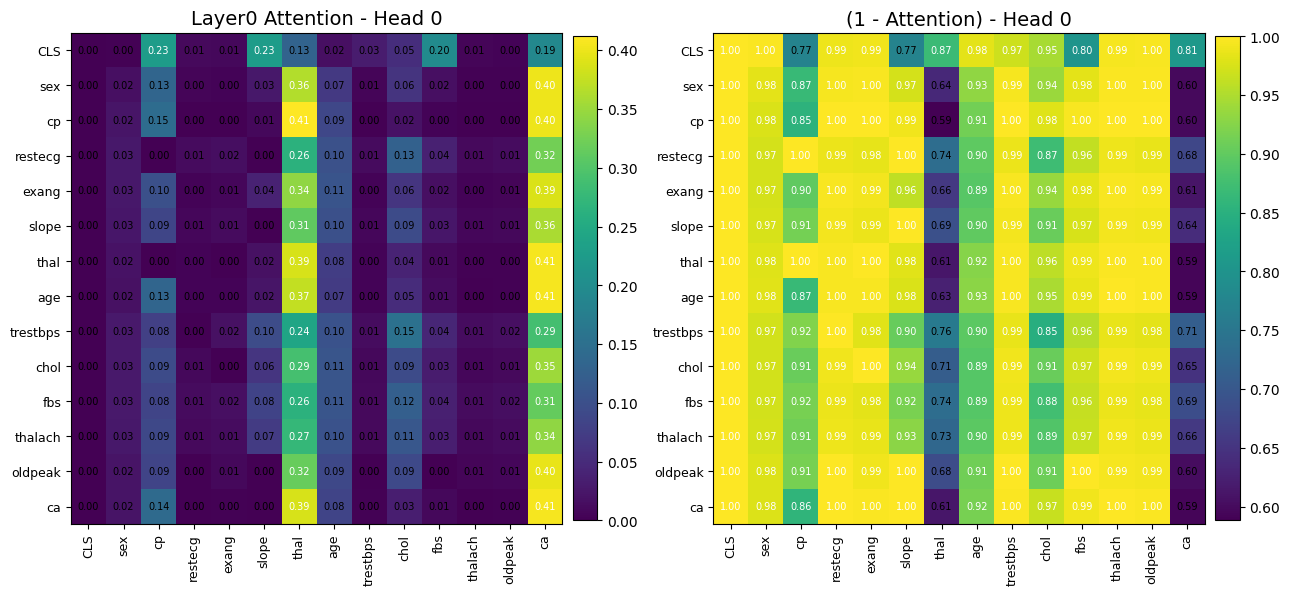

=== Embedding statistics per token (CLS + features) ===
            CLS  | mean=0.0075 | std=0.2499
            sex  | mean=0.0316 | std=2.2415
             cp  | mean=0.2809 | std=5.9927
        restecg  | mean=0.3125 | std=6.4842
          exang  | mean=0.0742 | std=2.6755
          slope  | mean=0.2337 | std=5.7133
           thal  | mean=0.2293 | std=5.3914
            age  | mean=-0.1276 | std=6.3909
       trestbps  | mean=0.0089 | std=0.2875
           chol  | mean=-0.2019 | std=4.6282
            fbs  | mean=-0.0899 | std=2.2040
        thalach  | mean=0.6194 | std=14.2193
        oldpeak  | mean=-0.2214 | std=5.3031
             ca  | mean=-0.0451 | std=2.0769

=== Global embedding statistics ===
global mean: 0.0794
global std : 5.6974


In [49]:
src = sources[0]   # 첫 source
loader = loaders[src]

batch = next(iter(loader))

atts, emb = extract_basis_attention_and_embedding(model, batch)

# feature names 가져오기
var_names = extract_feature_names(batch)
feature_names = ["CLS"] + var_names

# 첫 layer attention 시각화
#plot_attention_heatmap(atts[0], feature_names, "Layer0 Attention")
plot_attention_with_inverse(
    att=atts[0],
    feature_names=feature_names,
    title="Layer0 Attention",
    value_fontsize=7,
    tick_fontsize=9,
    title_fontsize=14,
    figsize_scale=1.3,
)
stats = summarize_embedding_stats(emb, feature_names)



In [31]:
emb.shape

(14, 768)

In [2]:
# import torch
# import torch.optim as optim
# import ot
# import matplotlib.pyplot as plt
# import numpy as np
# from sklearn.decomposition import PCA
# # UMAP 라이브러리가 설치되어 있어야 합니다 (pip install umap-learn)
# # UMAP 모듈 임포트 시도를 try/except로 감싸 안정성을 확보합니다.
# try:
#     import umap.umap_ as umap
#     UMAP_AVAILABLE = True
# except ImportError:
#     try:
#         import umap
#         UMAP_AVAILABLE = True
#     except ImportError:
#         print("UMAP not found. Falling back to PCA for visualization.")
#         UMAP_AVAILABLE = False

# # 실제 GW Loss 항의 최대값 계산
# # # C1의 최대값과 C2의 최소값(혹은 그 반대)의 차이의 제곱이 최대 비용이 됩니다.
# # gw_cost_max = (C1.max() - C2.min()) ** 2

# # print(f"1. Feature Cost (M) Max:      {M.max():,.2f}")
# # print(f"2. Structure Cost (GW) Max:   {gw_cost_max:,.2f} (Internal Term)")
# # print(f"3. Actual Ratio (GW / M):     {gw_cost_max / M.max():.2f}")
# # -----------------------------------------------------------------------------
# # 1. Setup Data
# # -----------------------------------------------------------------------------
# torch.manual_seed(42)
# np.random.seed(42)

# n_source = 20
# n_target = 30
# dim = 768
# EPSILON = 1e-9 # 0으로 나누는 것을 방지하기 위한 작은 값

# # [Target Data]: Target 클러스터 내부 분산을 10배 키워서 (0.1 -> 1.0) UMAP이 퍼뜨리도록 유도
# target_emb = torch.randn(n_target, dim) * 1.0 # 분산 증대 (이전 0.1)
# # target_emb[:n_target//2] += 2.0 # Cluster 1: +2.0
# # target_emb[n_target//2:] -= 2.0 # Cluster 2: -2.0

# # Source Data (Learnable): Target과 겹쳐서 시작
# source_emb = torch.randn(n_source, dim, requires_grad=True)

# # 초기화 연산을 .data를 이용해 수행하여 Leaf 상태를 유지합니다.
# with torch.no_grad():
#     source_emb.data *= 0.01 # 시작 분산을 극도로 작게 (거의 한 점)

# # Distribution weights
# p = ot.unif(n_source, type_as=source_emb)
# q = ot.unif(n_target, type_as=target_emb)

# # -----------------------------------------------------------------------------
# # 2. Training Loop (Robust Normalization)
# # -----------------------------------------------------------------------------
# optimizer = optim.SGD([source_emb], lr=0.5) 

# print("Start Training (UMAP Trajectory Enabled - Increased Target Variance)...")
# loss_history = []
# feat_cost_history = []
# struc_cost_history = []

# # Plan 시각화용
# snapshot_epochs = [0, 100, 1000, 2500, 4900]
# plan_snapshots = {}
# alpha = 0.0

# # 초기 상태
# source_history = [source_emb.detach().cpu().numpy().copy()]

# # [핵심 수정] 최종 수렴 확인을 위해 5000 Epoch으로 늘림
# n_epochs = 5000
# for epoch in range(n_epochs):
#     optimizer.zero_grad()

#     # --- Matrix Computation ---
#     M_raw = ot.dist(source_emb, target_emb)
#     C1_raw = ot.dist(source_emb, source_emb)
#     C2_raw = ot.dist(target_emb, target_emb)

#     # Robust Max Normalization (NaN 방지)
#     M = M_raw / (M_raw.max() + EPSILON) 
#     C1 = C1_raw / (C1_raw.max() + EPSILON)
#     C2 = C2_raw / (C2_raw.max() + EPSILON)

#     # --- FGW Loss ---
#     fgw_loss = ot.gromov.fused_gromov_wasserstein2(
#     M, C1, C2, p, q,
#     loss_fun='square_loss', alpha=alpha
#     )

#     if torch.isnan(fgw_loss):
#         print("Loss is NaN! Stopping training.")
#         break

#     # --- Update ---
#     fgw_loss.backward()
#     optimizer.step()

#     loss_history.append(fgw_loss.item())

#     # [로그 출력]
#     if epoch % 100 == 0:
#         with torch.no_grad():
#             T = ot.gromov.fused_gromov_wasserstein(M, C1, C2, p, q, loss_fun = 'square_loss', alpha = alpha)
#             if epoch in snapshot_epochs:
#                 plan_snapshots[epoch] = T.detach().cpu().numpy() 
#             current_feat_cost = torch.sum(M * T).item() 
#             constC, hC1, hC2 = ot.gromov.init_matrix(C1, C2, p, q, 'square_loss')
#             current_struc_cost = ot.gromov.gwloss(constC, hC1, hC2, T).item() 
#             feat_cost_history.append(current_feat_cost)
#             struc_cost_history.append(current_struc_cost)
#             weight_feat = (1 - alpha) * current_feat_cost 
#             weighted_struc = alpha * current_struc_cost 
#             total_weight = weighted_feat + weighted_struc + EPSILON
#             raw_m_max = M_raw.max().item()
#             c1_max_val = C1.max().item() 
#         gw_max_cost = (C1_raw.max().item() - C1_raw.min().item())**2
#         actual_ratio = gw_cost_max / (raw_m_max + EPSILON)
#         if len(source_history) > 0: 
#             prev_emb = source_history[-1]
#             curr_emb = source_emb.detach().cpu().numpy() 
#             diff = np.linalg.norm(curr_emb - prev_emb, axis = 1).mean() 
#             print(f"   [Movement] Avg Step Size (vs last snapshot): {diff:.6f}")
#             init_emb = source_history[0]
#             displacement = np.linalg.norm(curr_emb - init_emb, axis = 1).mean() 
#             print(f"   [Displacement] Avg Distance from Start:    {displacement:.6f}")
#         if source_emb.grad is not None:
#             grad_norm = source_emb.grad.norm().item() 
#             print(f"   [Gradient] Total Grad Norm:    {grad_norm:.6f}")

#         print("-" * 50)
#         print(f"Epoch {epoch:4d} | FGW Loss: {fgw_loss.item():.6f}")
#         print("   [RAW COST SCALE COMPARISON]")
#         print(f"   1. Feature Cost (M) Max:      {raw_m_max:,.2f}")
#         print(f"   2. Structure Cost (GW) Max:   {gw_max_cost:,.2f} (Internal Term)")
#         print(f"   3. Actual Ratio (GW / M):    {actual_ratio:,.2f}")
#         print(f"   4. source embedding norm : {source_emb.norm().item()} source embedding mean : {source_emb.mean().item()} source embedding grad : {source_emb.grad.mean().item()}")
#         # 매 스텝 저장
#         print(f"Epoch {epoch:4d} | Total Loss: {fgw_loss.item():.6f}")
#         print(f"  [Input Scales] M Max: {raw_m_max:.1f} (Raw) vs C1 Max: {c1_max_val:.4f} (Raw)")
#         print(f"  [Contribution] Feat: {weighted_feat:.1f} ({weighted_feat/total_weight:.1%}) vs Struc: {weighted_struc:.4f} ({weighted_struc/total_weight:.1%})")
        
#         source_history.append(source_emb.detach().cpu().numpy().copy())

# # 최종 상태
# source_history.append(source_emb.detach().cpu().numpy().copy())
# print("-" * 50)
# print(f"Training finished. Final Loss: {loss_history[-1]:.6f}")


# # -----------------------------------------------------------------------------
# # 3. Visualization: Trajectories (UMAP 2D Projection - ALL DATA)
# # -----------------------------------------------------------------------------
# print("Visualizing Trajectories with UMAP (Optimized Scaling)...")
# projection_method = "UMAP"

# # [핵심 수정] 모든 시점의 Source와 Target을 합쳐서 UMAP을 단 1회 수행합니다.
# all_data = np.vstack(source_history + [target_emb.numpy()])

# if UMAP_AVAILABLE:
#     # UMAP 변환기 (두 클러스터가 합쳐진 것을 보여줄 것입니다)
#     reducer = umap.UMAP(n_neighbors=5, min_dist=0.3, n_components=2, random_state=42)
#     data_2d = reducer.fit_transform(all_data)
# else:
#     # UMAP이 실패하면 PCA로 대체 (이전의 안정적인 fallback)
#     pca = PCA(n_components=2)
#     data_2d = pca.fit_transform(all_data)
#     projection_method = "PCA"

# # 데이터 분리
# target_2d = data_2d[-n_target:]
# source_2d_history = []
# start_idx = 0
# n_snapshots = len(source_history)
# for _ in range(n_snapshots):
#     end_idx = start_idx + n_source
#     source_2d_history.append(data_2d[start_idx:end_idx])
#     start_idx = end_idx

# source_2d_history = np.array(source_2d_history) 

# # 그래프 그리기
# plt.figure(figsize=(12, 8))
# ax = plt.gca() # 현재 축을 가져옵니다.

# # 1. Target (Goal) - 빨간색 X
# plt.scatter(target_2d[:, 0], target_2d[:, 1], c='red', marker='x', s=80, linewidths=2, label='Target (Goal)', zorder=2)

# # 2. Source Trajectories
# for i in range(n_source):
#     traj = source_2d_history[:, i, :]

#     # 이동 경로 선 (진한 회색)
#     plt.plot(traj[:, 0], traj[:, 1], color='gray', alpha=0.5, linewidth=1.5, zorder=1)

#     # 시작점 (하늘색)
#     plt.scatter(traj[0, 0], traj[0, 1], color='cyan', s=40, alpha=0.8, edgecolors='black', linewidth=0.5, zorder=3)

#     # 끝점 (진한 파랑)
#     plt.scatter(traj[-1, 0], traj[-1, 1], color='navy', s=80, edgecolors='white', linewidth=1.5, zorder=4)

# # [핵심 수정] UMAP/PCA 시각화에서는 축 비율을 1:1로 강제합니다.
# ax.set_aspect('equal', adjustable='box') 

# # Legend (가짜 핸들 생성)
# plt.scatter([], [], c='cyan', s=40, edgecolors='black', label='Source Start')
# plt.scatter([], [], c='navy', s=80, edgecolors='white', label='Source End')
# plt.plot([], [], color='gray', linewidth=1.5, label='Trajectory')

# plt.title(f"Optimization Trajectory ({projection_method} Projection, Equal Aspect Ratio) | Alpha={alpha}", fontsize=16)
# plt.legend(loc='upper right', fontsize=12)
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.tight_layout()
# plt.show()

# # -----------------------------------------------------------------------------
# # 4. Visualization: Cost Evolution (Dual Axis required due to scale)
# # -----------------------------------------------------------------------------
# print("Visualizing Cost Evolution (Raw Scales)...")
# epochs_range = range(0, n_epochs + 100, 100)[:len(feat_cost_history)]

# fig, ax1 = plt.subplots(figsize=(12, 6))

# color1 = 'tab:blue'
# ax1.set_xlabel('Epoch')
# ax1.set_ylabel('Raw Feature Cost (~Thousands)', color=color1, fontsize=12, fontweight='bold')
# ax1.plot(epochs_range, feat_cost_history, color=color1, linewidth=2, label='Feature Cost')
# ax1.tick_params(axis='y', labelcolor=color1)
# ax1.grid(True, alpha=0.3)

# ax2 = ax1.twinx() 
# color2 = 'tab:red'
# ax2.set_ylabel('Raw Structure Cost (~Ones)', color=color2, fontsize=12, fontweight='bold')
# ax2.plot(epochs_range, struc_cost_history, color=color2, linestyle='--', linewidth=2, label='Structure Cost')
# ax2.tick_params(axis='y', labelcolor=color2)

# plt.title(f"Cost Evolution (Alpha={alpha}, NO Normalization)", fontsize=16)
# plt.tight_layout()
# plt.show()

# # -----------------------------------------------------------------------------
# # 5. Visualization: Transport Plan Snapshots (Improved)
# # -----------------------------------------------------------------------------
# if plan_snapshots:
#     print("Visualizing Transport Plans...")
    
#     def plot_single_plan(ax, matrix, title):
#         im = ax.imshow(matrix, cmap="Blues", interpolation="nearest", aspect='auto')
#         ax.set_title(title, fontsize=12, pad=10)
#         ax.set_xlabel("Target Index", fontsize=10)
#         ax.set_ylabel("Source Index", fontsize=10)
#         ax.tick_params(axis='both', which='major', labelsize=8)

#         divider = make_axes_locatable(ax)
#         cax = divider.append_axes("right", size="5%", pad=0.1)
#         cb = plt.colorbar(im, cax=cax)
#         cb.ax.tick_params(labelsize=8)
#         return ax

#     n_snaps = len(plan_snapshots)
#     fig, axes = plt.subplots(1, n_snaps, figsize=(5 * n_snaps, 5), constrained_layout=True)
    
#     if n_snaps == 1: axes = [axes]
    
#     sorted_epochs = sorted(plan_snapshots.keys())
#     for i, epoch in enumerate(sorted_epochs):
#         plot_single_plan(axes[i], plan_snapshots[epoch], f"Plan (Epoch {epoch})")
    
#     plt.suptitle(f"Transport Plan Evolution (Alpha={alpha}, No Norm)", fontsize=16, y=1.02)
#     plt.show()

In [3]:
# import torch
# import torch.optim as optim
# import ot
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.decomposition import PCA

# # UMAP 확인
# try:
#     import umap.umap_ as umap
#     UMAP_AVAILABLE = True
# except ImportError:
#     try:
#         import umap
#         UMAP_AVAILABLE = True
#     except ImportError:
#         print("UMAP not found. Falling back to PCA.")
#         UMAP_AVAILABLE = False

# # -----------------------------------------------------------------------------
# # 1. Setup Data
# # -----------------------------------------------------------------------------
# torch.manual_seed(42)
# np.random.seed(42)

# n_source = 20
# n_target = node.shape[0] # 13
# dim = 768
# EPSILON = 1e-9 

# # [Target Data]
# if isinstance(node, np.ndarray):
#     target_emb = torch.from_numpy(node).float()
# else:
#     target_emb = node.detach().clone().float()

# # [Target Standardization]
# t_mean = target_emb.mean(dim=0)
# t_std = target_emb.std(dim=0) + EPSILON
# target_emb = (target_emb - t_mean) / t_std

# # [Target Structure (C2)] Stretched 1-Affinity
# attn_matrix = torch.tensor(atts[0], dtype=torch.float32).squeeze()
# if attn_matrix.dim() == 3: attn_matrix = attn_matrix.mean(dim=0)
# attn_matrix = attn_matrix[1:, 1:] # CLS 제거

# # 1. Affinity -> Cost
# C2_raw = 1.0 - attn_matrix 
# C2_raw.fill_diagonal_(0.0) 

# # (옵션) Setup 단계에서의 Min-Max Stretching은 데이터 전처리이므로 유지
# # 이것은 "분포"를 0~1로 펴주는 것이지, 매 step마다 크기를 죽이는 Normalization과는 다름
# # c2_min = C2_raw.min()
# # c2_max = C2_raw.max()
# # C2_raw = (C2_raw - c2_min) / (c2_max - c2_min + EPSILON)

# # [Source Data]
# source_emb = torch.randn(n_source, dim, requires_grad=True)
# with torch.no_grad():
#     source_emb.data *= 0.01 

# # Weights
# p = ot.unif(n_source, type_as=source_emb)
# q = ot.unif(n_target, type_as=source_emb)

# # Device
# device = source_emb.device
# target_emb = target_emb.to(device)
# C2_raw = C2_raw.to(device)

# # -----------------------------------------------------------------------------
# # 2. Training Loop
# # -----------------------------------------------------------------------------
# optimizer = optim.SGD([source_emb], lr=0.5) 

# # Feature와 Structure의 스케일이 자연스럽게 0~1 근처로 맞춰졌으므로
# # Alpha는 0.5 ~ 0.8 사이 추천
# alpha = 0.8
# n_epochs = 5000

# print(f"Start Training (Feature MaxNorm: ON, Structure MaxNorm: OFF, Alpha={alpha})...")

# loss_history = []
# feat_cost_history = []
# struc_cost_history = []
# source_history = [source_emb.detach().cpu().numpy().copy()]

# for epoch in range(n_epochs):
#     optimizer.zero_grad()

#     # ----------------------------------------------------------------
#     # 1. Feature Cost (M): Euclidean
#     # ----------------------------------------------------------------
#     # 값 범위: ~3000 (Standardized 768 dim)
#     M_raw = ot.dist(source_emb, target_emb)
    
#     # ----------------------------------------------------------------
#     # 2. Structure Cost (C1): Cosine Distance
#     # ----------------------------------------------------------------
#     # 값 범위: 0.0 ~ 2.0
#     source_norm = torch.nn.functional.normalize(source_emb, p=2, dim=1)
#     cosine_sim = torch.mm(source_norm, source_norm.t())
#     C1_raw = 1.0 - cosine_sim
#     C1_raw = torch.clamp(C1_raw, min=0.0)
#     C1_raw.fill_diagonal_(0.0)

#     # ----------------------------------------------------------------
#     # 3. Normalization (Feature ONLY)
#     # ----------------------------------------------------------------
#     # [요청 반영] Feature는 3000 -> 1.0으로 압축 (필수)
#     m_max = M_raw.max().detach() + EPSILON
#     M = M_raw / m_max
    
#     # [요청 반영] Structure는 Normalization 제거 (Raw Scale 사용)
#     # C1(0~2), C2(0~1) 범위 그대로 들어갑니다.
#     C1 = C1_raw 
#     C2 = C2_raw 

#     # FGW Loss
#     fgw_loss = ot.gromov.fused_gromov_wasserstein2(
#         M, C1, C2, p, q,
#         loss_fun='square_loss', alpha=alpha
#     )

#     if torch.isnan(fgw_loss):
#         print("Loss is NaN! Stopping.")
#         break

#     fgw_loss.backward()
#     optimizer.step()
#     loss_history.append(fgw_loss.item())

#     # Logging & Stats
#     if epoch % 100 == 0:
#         with torch.no_grad():
#             # Contribution 계산
#             T = ot.gromov.fused_gromov_wasserstein(M, C1, C2, p, q, loss_fun='square_loss', alpha=alpha)
            
#             # Normalized Feature Cost
#             current_feat_cost = torch.sum(M * T).item()
            
#             # Un-Normalized Structure Cost
#             # init_matrix는 원래 C1, C2를 그대로 씁니다.
#             constC, hC1, hC2 = ot.gromov.init_matrix(C1, C2, p, q, 'square_loss')
#             current_struc_cost = ot.gromov.gwloss(constC, hC1, hC2, T).item()
            
#             feat_cost_history.append(current_feat_cost)
#             struc_cost_history.append(current_struc_cost)
            
#             weighted_feat = (1 - alpha) * current_feat_cost
#             weighted_struc = alpha * current_struc_cost
#             total_weight = weighted_feat + weighted_struc + EPSILON
            
#             raw_m_max = M_raw.max().item()
#             # 구조 비용의 Raw Max (Source 구조가 0~2 범위인지 확인)
#             c1_max_val = C1_raw.max().item()

#         print(f"Epoch {epoch:4d} | Total Loss: {fgw_loss.item():.6f}")
#         print(f"  [Scales]       M Raw Max: {raw_m_max:.1f} -> Norm Max: 1.0")
#         print(f"                 C1 Raw Max: {c1_max_val:.4f} (No Norm applied)")
#         print(f"  [Contribution] Feat: {weighted_feat:.4f} ({weighted_feat/total_weight:.1%}) vs Struc: {weighted_struc:.4f} ({weighted_struc/total_weight:.1%})")
        
#         source_history.append(source_emb.detach().cpu().numpy().copy())

# source_history.append(source_emb.detach().cpu().numpy().copy())
# print("Training Finished.")

# # -----------------------------------------------------------------------------
# # 3. Visualization
# # -----------------------------------------------------------------------------
# print("Visualizing Trajectories...")
# target_numpy = target_emb.detach().cpu().numpy()
# all_data = np.vstack(source_history + [target_numpy])

# if UMAP_AVAILABLE:
#     reducer = umap.UMAP(n_neighbors=min(15, n_target-1), min_dist=0.1, n_components=2, random_state=42)
#     data_2d = reducer.fit_transform(all_data)
#     projection_method = "UMAP"
# else:
#     pca = PCA(n_components=2)
#     data_2d = pca.fit_transform(all_data)
#     projection_method = "PCA"

# target_2d = data_2d[-n_target:]
# source_2d_history = []
# start_idx = 0
# n_snapshots = len(source_history)

# for _ in range(n_snapshots):
#     end_idx = start_idx + n_source
#     source_2d_history.append(data_2d[start_idx:end_idx])
#     start_idx = end_idx
# source_2d_history = np.array(source_2d_history)

# plt.figure(figsize=(10, 8))
# plt.scatter(target_2d[:, 0], target_2d[:, 1], c='red', marker='x', s=80, label='Target (Goal)', zorder=2)
# for i in range(n_source):
#     traj = source_2d_history[:, i, :]
#     plt.plot(traj[:, 0], traj[:, 1], color='gray', alpha=0.3, linewidth=1)
#     plt.scatter(traj[0, 0], traj[0, 1], color='cyan', s=20, zorder=3, edgecolors='k', linewidth=0.5)
#     plt.scatter(traj[-1, 0], traj[-1, 1], color='navy', s=60, zorder=4, edgecolors='w', linewidth=1)

# plt.gca().set_aspect('equal', adjustable='box')
# plt.title(f"Optimization Trajectory ({projection_method}) | Alpha={alpha}")
# plt.legend()
# plt.tight_layout()
# plt.show()

# # -----------------------------------------------------------------------------
# # 4. Visualization: Dual Axis Plot
# # -----------------------------------------------------------------------------
# print("Visualizing Cost Evolution...")
# epochs_range = range(0, n_epochs + 100, 100)[:len(feat_cost_history)]

# fig, ax1 = plt.subplots(figsize=(12, 6))

# color1 = 'tab:blue'
# ax1.set_xlabel('Epoch')
# ax1.set_ylabel('Feature Cost (Max Norm)', color=color1, fontsize=12, fontweight='bold')
# ax1.plot(epochs_range, feat_cost_history, color=color1, linewidth=2, label='Feature Cost')
# ax1.tick_params(axis='y', labelcolor=color1)
# ax1.grid(True, alpha=0.3)

# ax2 = ax1.twinx() 
# color2 = 'tab:red'
# ax2.set_ylabel('Structure Cost (No Norm)', color=color2, fontsize=12, fontweight='bold')
# ax2.plot(epochs_range, struc_cost_history, color=color2, linestyle='--', linewidth=2, label='Structure Cost')
# ax2.tick_params(axis='y', labelcolor=color2)

# plt.title(f"Cost Evolution (Alpha={alpha}, Struct Norm OFF)", fontsize=16)
# plt.tight_layout()
# plt.show()

In [4]:
# import torch
# import torch.optim as optim
# import ot
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.decomposition import PCA
# from mpl_toolkits.axes_grid1 import make_axes_locatable # 컬러바 정렬을 위해 추가

# # UMAP 확인
# try:
#     import umap.umap_ as umap
#     UMAP_AVAILABLE = True
# except ImportError:
#     try:
#         import umap
#         UMAP_AVAILABLE = True
#     except ImportError:
#         print("UMAP not found. Falling back to PCA.")
#         UMAP_AVAILABLE = False

# # -----------------------------------------------------------------------------
# # 1. Setup Data
# # -----------------------------------------------------------------------------
# torch.manual_seed(42)
# np.random.seed(42)

# n_source = 20
# n_target = node.shape[0] # 13
# dim = 768
# EPSILON = 1e-9 

# # [Target Data]
# if isinstance(node, np.ndarray):
#     target_emb = torch.from_numpy(node).float()
# else:
#     target_emb = node.detach().clone().float()

# # [Target Standardization]
# t_mean = target_emb.mean(dim=0)
# t_std = target_emb.std(dim=0) + EPSILON
# target_emb = (target_emb - t_mean) / t_std

# # [Target Structure (C2)] Stretched 1-Affinity
# attn_matrix = torch.tensor(atts[0], dtype=torch.float32).squeeze()
# if attn_matrix.dim() == 3: attn_matrix = attn_matrix.mean(dim=0)
# attn_matrix = attn_matrix[1:, 1:] # CLS 제거

# # 1. Affinity -> Cost
# C2_raw = 1.0 - attn_matrix 
# C2_raw.fill_diagonal_(0.0) 

# # (옵션) Setup 단계에서의 Min-Max Stretching은 데이터 전처리이므로 유지
# c2_min = C2_raw.min()
# c2_max = C2_raw.max()
# C2_raw = (C2_raw - c2_min) / (c2_max - c2_min + EPSILON)

# # [Source Data]
# source_emb = torch.randn(n_source, dim, requires_grad=True)
# with torch.no_grad():
#     source_emb.data *= 0.01 

# # Weights
# p = ot.unif(n_source, type_as=source_emb)
# q = ot.unif(n_target, type_as=source_emb)

# # Device
# device = source_emb.device
# target_emb = target_emb.to(device)
# C2_raw = C2_raw.to(device)

# # -----------------------------------------------------------------------------
# # 2. Training Loop
# # -----------------------------------------------------------------------------
# optimizer = optim.SGD([source_emb], lr=0.5) 

# # Feature(Norm ON)와 Structure(Norm OFF)의 밸런스 조절
# alpha = 0.8 
# n_epochs = 5000

# print(f"Start Training (Feature MaxNorm: ON, Structure MaxNorm: OFF, Alpha={alpha})...")

# loss_history = []
# feat_cost_history = []
# struc_cost_history = []
# source_history = [source_emb.detach().cpu().numpy().copy()]

# # [Plan 시각화 설정]
# snapshot_epochs = [0, 100, 1000, 2500, 4900] # Plan을 저장할 시점
# plan_snapshots = {}

# for epoch in range(n_epochs):
#     optimizer.zero_grad()

#     # ----------------------------------------------------------------
#     # 1. Feature Cost (M): Euclidean
#     # ----------------------------------------------------------------
#     M_raw = ot.dist(source_emb, target_emb)
    
#     # ----------------------------------------------------------------
#     # 2. Structure Cost (C1): Cosine Distance
#     # ----------------------------------------------------------------
#     source_norm = torch.nn.functional.normalize(source_emb, p=2, dim=1)
#     cosine_sim = torch.mm(source_norm, source_norm.t())
#     C1_raw = 1.0 - cosine_sim
#     C1_raw = torch.clamp(C1_raw, min=0.0)
#     C1_raw.fill_diagonal_(0.0)

#     # ----------------------------------------------------------------
#     # 3. Normalization (Feature ONLY)
#     # ----------------------------------------------------------------
#     # Feature는 3000 -> 1.0으로 압축
#     m_max = M_raw.max().detach() + EPSILON
#     M = M_raw / m_max
    
#     # Structure는 Raw Scale 사용 (0~2 범위)
#     C1 = C1_raw 
#     C2 = C2_raw 

#     # FGW Loss
#     fgw_loss = ot.gromov.fused_gromov_wasserstein2(
#         M, C1, C2, p, q,
#         loss_fun='square_loss', alpha=alpha
#     )

#     if torch.isnan(fgw_loss):
#         print("Loss is NaN! Stopping.")
#         break

#     fgw_loss.backward()
#     optimizer.step()
#     loss_history.append(fgw_loss.item())

#     # Logging & Stats
#     if epoch % 100 == 0:
#         with torch.no_grad():
#             # Plan T 계산 (시각화 및 Contribution 용)
#             T = ot.gromov.fused_gromov_wasserstein(M, C1, C2, p, q, loss_fun='square_loss', alpha=alpha)
            
#             # 스냅샷 저장
#             if epoch in snapshot_epochs:
#                 plan_snapshots[epoch] = T.detach().cpu().numpy()

#             # Normalized Feature Cost
#             current_feat_cost = torch.sum(M * T).item()
            
#             # Un-Normalized Structure Cost
#             constC, hC1, hC2 = ot.gromov.init_matrix(C1, C2, p, q, 'square_loss')
#             current_struc_cost = ot.gromov.gwloss(constC, hC1, hC2, T).item()
            
#             feat_cost_history.append(current_feat_cost)
#             struc_cost_history.append(current_struc_cost)
            
#             weighted_feat = (1 - alpha) * current_feat_cost
#             weighted_struc = alpha * current_struc_cost
#             total_weight = weighted_feat + weighted_struc + EPSILON
            
#             raw_m_max = M_raw.max().item()
#             c1_max_val = C1_raw.max().item()

#         print(f"Epoch {epoch:4d} | Total Loss: {fgw_loss.item():.6f}")
#         print(f"  [Scales]       M Raw Max: {raw_m_max:.1f} -> Norm Max: 1.0")
#         print(f"                 C1 Raw Max: {c1_max_val:.4f} (No Norm applied)")
#         print(f"  [Contribution] Feat: {weighted_feat:.4f} ({weighted_feat/total_weight:.1%}) vs Struc: {weighted_struc:.4f} ({weighted_struc/total_weight:.1%})")
        
#         source_history.append(source_emb.detach().cpu().numpy().copy())

# source_history.append(source_emb.detach().cpu().numpy().copy())
# print("Training Finished.")

# # -----------------------------------------------------------------------------
# # 3. Visualization: Trajectories
# # -----------------------------------------------------------------------------
# print("Visualizing Trajectories...")
# target_numpy = target_emb.detach().cpu().numpy()
# all_data = np.vstack(source_history + [target_numpy])

# if UMAP_AVAILABLE:
#     reducer = umap.UMAP(n_neighbors=min(15, n_target-1), min_dist=0.1, n_components=2, random_state=42)
#     data_2d = reducer.fit_transform(all_data)
#     projection_method = "UMAP"
# else:
#     pca = PCA(n_components=2)
#     data_2d = pca.fit_transform(all_data)
#     projection_method = "PCA"

# target_2d = data_2d[-n_target:]
# source_2d_history = np.array(source_2d_history)
# source_2d_history = []
# start_idx = 0
# n_snapshots = len(source_history)
# for _ in range(n_snapshots):
#     end_idx = start_idx + n_source
#     source_2d_history.append(data_2d[start_idx:end_idx])
#     start_idx = end_idx
# source_2d_history = np.array(source_2d_history)

# plt.figure(figsize=(10, 8))
# plt.scatter(target_2d[:, 0], target_2d[:, 1], c='red', marker='x', s=80, label='Target (Goal)', zorder=2)
# for i in range(n_source):
#     traj = source_2d_history[:, i, :]
#     plt.plot(traj[:, 0], traj[:, 1], color='gray', alpha=0.3, linewidth=1)
#     plt.scatter(traj[0, 0], traj[0, 1], color='cyan', s=20, zorder=3, edgecolors='k', linewidth=0.5)
#     plt.scatter(traj[-1, 0], traj[-1, 1], color='navy', s=60, zorder=4, edgecolors='w', linewidth=1)

# plt.gca().set_aspect('equal', adjustable='box')
# plt.title(f"Optimization Trajectory ({projection_method}) | Alpha={alpha}")
# plt.legend()
# plt.tight_layout()
# plt.show()

# # -----------------------------------------------------------------------------
# # 4. Visualization: Dual Axis Plot
# # -----------------------------------------------------------------------------
# print("Visualizing Cost Evolution...")
# epochs_range = range(0, n_epochs + 100, 100)[:len(feat_cost_history)]

# fig, ax1 = plt.subplots(figsize=(12, 6))

# color1 = 'tab:blue'
# ax1.set_xlabel('Epoch')
# ax1.set_ylabel('Feature Cost (Max Norm)', color=color1, fontsize=12, fontweight='bold')
# ax1.plot(epochs_range, feat_cost_history, color=color1, linewidth=2, label='Feature Cost')
# ax1.tick_params(axis='y', labelcolor=color1)
# ax1.grid(True, alpha=0.3)

# ax2 = ax1.twinx() 
# color2 = 'tab:red'
# ax2.set_ylabel('Structure Cost (No Norm)', color=color2, fontsize=12, fontweight='bold')
# ax2.plot(epochs_range, struc_cost_history, color=color2, linestyle='--', linewidth=2, label='Structure Cost')
# ax2.tick_params(axis='y', labelcolor=color2)

# plt.title(f"Cost Evolution (Alpha={alpha}, Struct Norm OFF)", fontsize=16)
# plt.tight_layout()
# plt.show()

# # -----------------------------------------------------------------------------
# # 5. Visualization: Transport Plan Snapshots (개선된 버전)
# # -----------------------------------------------------------------------------
# if plan_snapshots:
#     print("Visualizing Transport Plans...")
    
#     def plot_single_plan(ax, matrix, title):
#         im = ax.imshow(matrix, cmap="Blues", interpolation="nearest", aspect='auto') # aspect='auto' 추가
#         ax.set_title(title, fontsize=12, pad=10) # 폰트 크기 조절
#         ax.set_xlabel("Target Index", fontsize=10) # 구체적인 라벨
#         ax.set_ylabel("Source Index", fontsize=10) # 구체적인 라벨
#         ax.tick_params(axis='both', which='major', labelsize=8)

#         # 컬러바를 그림에 깔끔하게 정렬
#         divider = make_axes_locatable(ax)
#         cax = divider.append_axes("right", size="5%", pad=0.1) # 컬러바 크기/패딩 조절
#         cb = plt.colorbar(im, cax=cax)
#         cb.ax.tick_params(labelsize=8)
#         return ax

#     n_snaps = len(plan_snapshots)
#     fig, axes = plt.subplots(1, n_snaps, figsize=(5 * n_snaps, 5), constrained_layout=True)
    
#     # axes가 리스트가 아닌 단일 객체일 경우를 대비 (스냅샷이 하나일 때)
#     if n_snaps == 1: 
#         axes = [axes]
    
#     sorted_epochs = sorted(plan_snapshots.keys())
#     for i, epoch in enumerate(sorted_epochs):
#         plot_single_plan(axes[i], plan_snapshots[epoch], f"Plan (Epoch {epoch})")
    
#     plt.suptitle(f"Transport Plan Evolution (Alpha={alpha})", fontsize=16, y=1.02) # y값 조정
#     plt.show()

In [5]:
# import torch
# import torch.optim as optim
# import ot
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.decomposition import PCA
# from mpl_toolkits.axes_grid1 import make_axes_locatable

# # UMAP 확인
# try:
#     import umap.umap_ as umap
#     UMAP_AVAILABLE = True
# except ImportError:
#     try:
#         import umap
#         UMAP_AVAILABLE = True
#     except ImportError:
#         print("UMAP not found. Falling back to PCA.")
#         UMAP_AVAILABLE = False

# # -----------------------------------------------------------------------------
# # 1. Setup Data
# # -----------------------------------------------------------------------------
# torch.manual_seed(42)
# np.random.seed(42)

# n_source = 20
# n_target = node.shape[0] # 13
# dim = 768
# EPSILON = 1e-9 

# # [Target Data]
# if isinstance(node, np.ndarray):
#     target_emb = torch.from_numpy(node).float()
# else:
#     target_emb = node.detach().clone().float()

# # [Target Standardization] (데이터 자체의 특이성 보존을 위해 유지)
# # t_mean = target_emb.mean(dim=0)
# # t_std = target_emb.std(dim=0) + EPSILON
# # target_emb = (target_emb - t_mean) / t_std

# # [Target Structure (C2)] Stretched 1-Affinity
# attn_matrix = torch.tensor(atts[0], dtype=torch.float32).squeeze()
# if attn_matrix.dim() == 3: attn_matrix = attn_matrix.mean(dim=0)
# attn_matrix = attn_matrix[1:, 1:] # CLS 제거

# # 1. Affinity -> Cost
# C2_raw = 1.0 - attn_matrix 
# C2_raw.fill_diagonal_(0.0) 

# # (옵션) Setup 단계의 Min-Max는 데이터 전처리이므로 유지
# c2_min = C2_raw.min()
# c2_max = C2_raw.max()
# C2_raw = (C2_raw - c2_min) / (c2_max - c2_min + EPSILON)

# # [Source Data]
# source_emb = torch.randn(n_source, dim, requires_grad=True)
# with torch.no_grad():
#     source_emb.data *= 0.01 

# # Weights
# p = ot.unif(n_source, type_as=source_emb)
# q = ot.unif(n_target, type_as=source_emb)

# # Device
# device = source_emb.device
# target_emb = target_emb.to(device)
# C2_raw = C2_raw.to(device)

# # -----------------------------------------------------------------------------
# # 2. Training Loop
# # -----------------------------------------------------------------------------
# optimizer = optim.SGD([source_emb], lr=0.5) 

# # Alpha 설정
# alpha = 0.9999
# n_epochs = 5000

# print(f"Start Training (ALL Normalization: OFF, Alpha={alpha})...")
# print("Warning: Expecting massive scale imbalance between Feature and Structure.")

# loss_history = []
# feat_cost_history = []
# struc_cost_history = []
# source_history = [source_emb.detach().cpu().numpy().copy()]

# # Plan 시각화용
# snapshot_epochs = [0, 100, 1000, 2500, 4900]
# plan_snapshots = {}

# for epoch in range(n_epochs):
#     optimizer.zero_grad()

#     # ----------------------------------------------------------------
#     # 1. Feature Cost (M): Euclidean
#     # ----------------------------------------------------------------
#     # 값 범위: ~3200 (Standardized 768 dim)
#     M_raw = ot.dist(source_emb, target_emb)
    
#     # ----------------------------------------------------------------
#     # 2. Structure Cost (C1): Cosine Distance
#     # ----------------------------------------------------------------
#     # 값 범위: 0.0 ~ 2.0
#     source_norm = torch.nn.functional.normalize(source_emb, p=2, dim=1)
#     cosine_sim = torch.mm(source_norm, source_norm.t())
#     C1_raw = 1.0 - cosine_sim
#     C1_raw = torch.clamp(C1_raw, min=0.0)
#     C1_raw.fill_diagonal_(0.0)

#     # ----------------------------------------------------------------
#     # 3. NO Normalization (Raw Scale Experiment)
#     # ----------------------------------------------------------------
#     # [핵심] Normalization을 아예 하지 않습니다.
#     # M은 3000, C는 1.0인 상태 그대로 들어갑니다.
#     M = M_raw 
#     C1 = C1_raw 
#     C2 = C2_raw 

#     # FGW Loss
#     fgw_loss = ot.gromov.fused_gromov_wasserstein2(
#         M, C1, C2, p, q,
#         loss_fun='square_loss', alpha=alpha
#     )

#     if torch.isnan(fgw_loss):
#         print("Loss is NaN! Stopping.")
#         break

#     fgw_loss.backward()
#     optimizer.step()
#     loss_history.append(fgw_loss.item())

#     # Logging & Stats
#     if epoch % 100 == 0:
#         with torch.no_grad():
#             # Plan T 계산
#             T = ot.gromov.fused_gromov_wasserstein(M, C1, C2, p, q, loss_fun='square_loss', alpha=alpha)
            
#             # 스냅샷
#             if epoch in snapshot_epochs:
#                 plan_snapshots[epoch] = T.detach().cpu().numpy()

#             # Raw Feature Cost
#             current_feat_cost = torch.sum(M * T).item()
            
#             # Raw Structure Cost
#             constC, hC1, hC2 = ot.gromov.init_matrix(C1, C2, p, q, 'square_loss')
#             current_struc_cost = ot.gromov.gwloss(constC, hC1, hC2, T).item()
            
#             feat_cost_history.append(current_feat_cost)
#             struc_cost_history.append(current_struc_cost)
            
#             # 가중치가 적용된 '실제 영향력' 비교
#             # Normalization이 없으므로 M 값이 그대로 곱해져서 매우 클 것임
#             weighted_feat = (1 - alpha) * current_feat_cost
#             weighted_struc = alpha * current_struc_cost
#             total_weight = weighted_feat + weighted_struc + EPSILON
            
#             raw_m_max = M.max().item()
#             c1_max_val = C1.max().item()

#         print(f"Epoch {epoch:4d} | Total Loss: {fgw_loss.item():.6f}")
#         print(f"  [Input Scales] M Max: {raw_m_max:.1f} (Raw) vs C1 Max: {c1_max_val:.4f} (Raw)")
#         print(f"  [Contribution] Feat: {weighted_feat:.1f} ({weighted_feat/total_weight:.1%}) vs Struc: {weighted_struc:.4f} ({weighted_struc/total_weight:.1%})")
        
#         source_history.append(source_emb.detach().cpu().numpy().copy())

# source_history.append(source_emb.detach().cpu().numpy().copy())
# print("Training Finished.")

# # -----------------------------------------------------------------------------
# # 3. Visualization: Trajectories
# # -----------------------------------------------------------------------------
# print("Visualizing Trajectories...")
# target_numpy = target_emb.detach().cpu().numpy()
# all_data = np.vstack(source_history + [target_numpy])

# if UMAP_AVAILABLE:
#     reducer = umap.UMAP(n_neighbors=min(15, n_target-1), min_dist=0.1, n_components=2, random_state=42)
#     data_2d = reducer.fit_transform(all_data)
#     projection_method = "UMAP"
# else:
#     pca = PCA(n_components=2)
#     data_2d = pca.fit_transform(all_data)
#     projection_method = "PCA"

# target_2d = data_2d[-n_target:]
# source_2d_history = np.array(source_2d_history)
# source_2d_history = []
# start_idx = 0
# n_snapshots = len(source_history)
# for _ in range(n_snapshots):
#     end_idx = start_idx + n_source
#     source_2d_history.append(data_2d[start_idx:end_idx])
#     start_idx = end_idx
# source_2d_history = np.array(source_2d_history)

# plt.figure(figsize=(10, 8))
# plt.scatter(target_2d[:, 0], target_2d[:, 1], c='red', marker='x', s=80, label='Target (Goal)', zorder=2)
# for i in range(n_source):
#     traj = source_2d_history[:, i, :]
#     plt.plot(traj[:, 0], traj[:, 1], color='gray', alpha=0.3, linewidth=1)
#     plt.scatter(traj[0, 0], traj[0, 1], color='cyan', s=20, zorder=3, edgecolors='k', linewidth=0.5)
#     plt.scatter(traj[-1, 0], traj[-1, 1], color='navy', s=60, zorder=4, edgecolors='w', linewidth=1)

# plt.gca().set_aspect('equal', adjustable='box')
# plt.title(f"Optimization Trajectory ({projection_method}) | Alpha={alpha}, No Norm")
# plt.legend()
# plt.tight_layout()
# plt.show()

# # -----------------------------------------------------------------------------
# # 4. Visualization: Cost Evolution (Dual Axis required due to scale)
# # -----------------------------------------------------------------------------
# print("Visualizing Cost Evolution (Raw Scales)...")
# epochs_range = range(0, n_epochs + 100, 100)[:len(feat_cost_history)]

# fig, ax1 = plt.subplots(figsize=(12, 6))

# color1 = 'tab:blue'
# ax1.set_xlabel('Epoch')
# ax1.set_ylabel('Raw Feature Cost (~Thousands)', color=color1, fontsize=12, fontweight='bold')
# ax1.plot(epochs_range, feat_cost_history, color=color1, linewidth=2, label='Feature Cost')
# ax1.tick_params(axis='y', labelcolor=color1)
# ax1.grid(True, alpha=0.3)

# ax2 = ax1.twinx() 
# color2 = 'tab:red'
# ax2.set_ylabel('Raw Structure Cost (~Ones)', color=color2, fontsize=12, fontweight='bold')
# ax2.plot(epochs_range, struc_cost_history, color=color2, linestyle='--', linewidth=2, label='Structure Cost')
# ax2.tick_params(axis='y', labelcolor=color2)

# plt.title(f"Cost Evolution (Alpha={alpha}, NO Normalization)", fontsize=16)
# plt.tight_layout()
# plt.show()

# # -----------------------------------------------------------------------------
# # 5. Visualization: Transport Plan Snapshots (Improved)
# # -----------------------------------------------------------------------------
# if plan_snapshots:
#     print("Visualizing Transport Plans...")
    
#     def plot_single_plan(ax, matrix, title):
#         im = ax.imshow(matrix, cmap="Blues", interpolation="nearest", aspect='auto')
#         ax.set_title(title, fontsize=12, pad=10)
#         ax.set_xlabel("Target Index", fontsize=10)
#         ax.set_ylabel("Source Index", fontsize=10)
#         ax.tick_params(axis='both', which='major', labelsize=8)

#         divider = make_axes_locatable(ax)
#         cax = divider.append_axes("right", size="5%", pad=0.1)
#         cb = plt.colorbar(im, cax=cax)
#         cb.ax.tick_params(labelsize=8)
#         return ax

#     n_snaps = len(plan_snapshots)
#     fig, axes = plt.subplots(1, n_snaps, figsize=(5 * n_snaps, 5), constrained_layout=True)
    
#     if n_snaps == 1: axes = [axes]
    
#     sorted_epochs = sorted(plan_snapshots.keys())
#     for i, epoch in enumerate(sorted_epochs):
#         plot_single_plan(axes[i], plan_snapshots[epoch], f"Plan (Epoch {epoch})")
    
#     plt.suptitle(f"Transport Plan Evolution (Alpha={alpha}, No Norm)", fontsize=16, y=1.02)
#     plt.show()

In [50]:
import torch
import ot
from ot.backend import get_backend

# 배치 데이터 생성
batch_size = 32
n, m = 10, 8

# Source와 target distributions (batch)
a = torch.ones(batch_size, n) / n
b = torch.ones(batch_size, m) / m

# Cost matrices (batch)
xs = torch.randn(batch_size, n, 2)
xt = torch.randn(batch_size, m, 2)

# Structure matrices for Gromov-Wasserstein
C1 = torch.cdist(xs, xs)  # [batch, n, n]
C2 = torch.cdist(xt, xt)  # [batch, m, m]

# Feature cost for Fused GW
M = torch.cdist(xs, xt)   # [batch, n, m]

print("Testing batch Fused Gromov-Wasserstein...")

# Batch solve
from ot.batch import solve_gromov_batch

result = solve_gromov_batch(
    C1, C2,
    M=M,           # Feature cost (Fused)
    alpha=0.5,     # Balance between feature and structure
    reg=0.01,      # Entropic regularization
    a=a, b=b,
    max_iter=50
)

# OTResult 객체에서 transport plan 추출
T = result.value  # 또는 result.plan

print(f"✅ Success! Transport plan shape: {T.shape}")
print(f"Transport plan sum (should be ~1): {T[0].sum().item():.4f}")

# OTResult의 다른 속성들
print(f"\nOTResult attributes: {dir(result)}")

Testing batch Fused Gromov-Wasserstein...
✅ Success! Transport plan shape: torch.Size([32])
Transport plan sum (should be ~1): 0.6415

OTResult attributes: ['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_backend', '_batch_size', '_lazy_plan', '_log', '_plan', '_potentials', '_sparse_plan', '_status', '_value', '_value_linear', '_value_quad', 'a_to_b', 'b_to_a', 'citation', 'lazy_plan', 'log', 'marginal_a', 'marginal_b', 'marginals', 'plan', 'potential_a', 'potential_b', 'potentials', 'sparse_plan', 'status', 'value', 'value_linear', 'value_quad']


Training with source: Heart_disease_statlog
Model input_dim: 768
Learnable graphs: M=8, K=8, D=768

===== Epoch 1 =====
Batch 0, Loss: 0.4403 (FGW: 0.3693, Orth: 0.7097)
  Total FGW (first sample): [0.319417   0.48017612 0.4012967  0.41819808 0.4718048  0.42910564
 0.14604703 0.4666794 ]
  Feature cost (first sample): [0.05690038 0.05695863 0.05690427 0.05693556 0.05692261 0.05699002
 0.05692323 0.05699082]
  Structure cost (first sample): [0.26251662 0.42321748 0.34439245 0.36126253 0.41488218 0.3721156
 0.0891238  0.4096886 ]
Epoch 1 - Average Loss: 0.4408

===== Epoch 2 =====
Batch 0, Loss: 0.4106 (FGW: 0.3466, Orth: 0.6393)
  Total FGW (first sample): [0.24961583 0.4802297  0.3796953  0.40742725 0.46734723 0.41376424
 0.12412089 0.46501902]
  Feature cost (first sample): [0.05693369 0.05699185 0.05693851 0.05696516 0.05695587 0.05701697
 0.05696701 0.05702165]
  Structure cost (first sample): [0.19268215 0.42323786 0.3227568  0.35046208 0.41039136 0.35674727
 0.06715388 0.40799737]

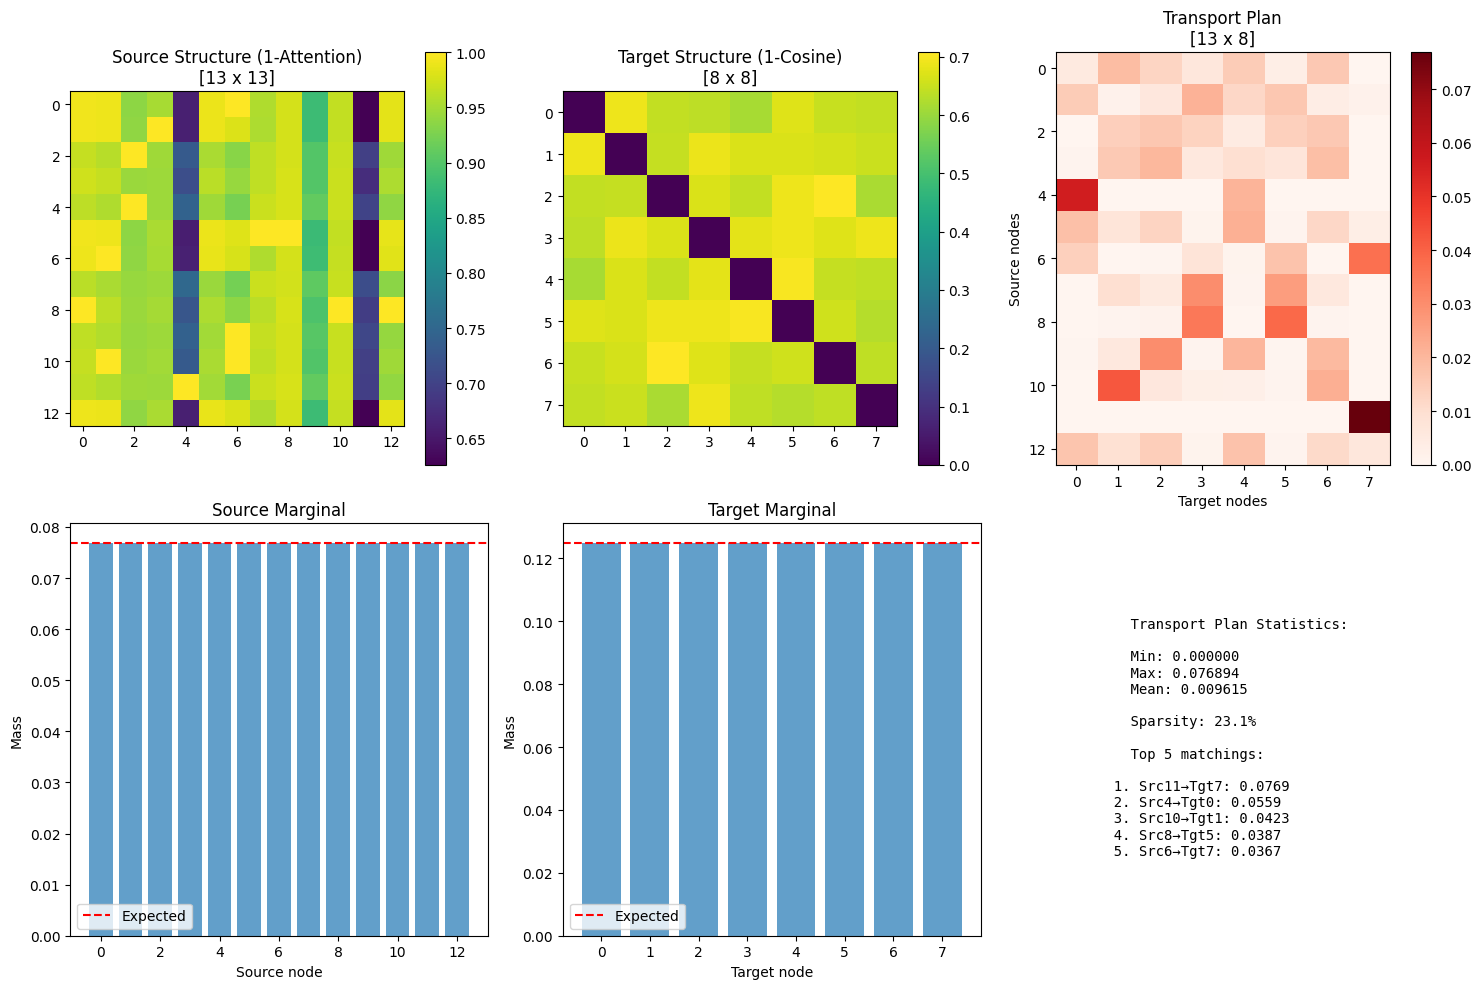

✅ Visualization saved!

Visualizing Sample 1 with Graph 1


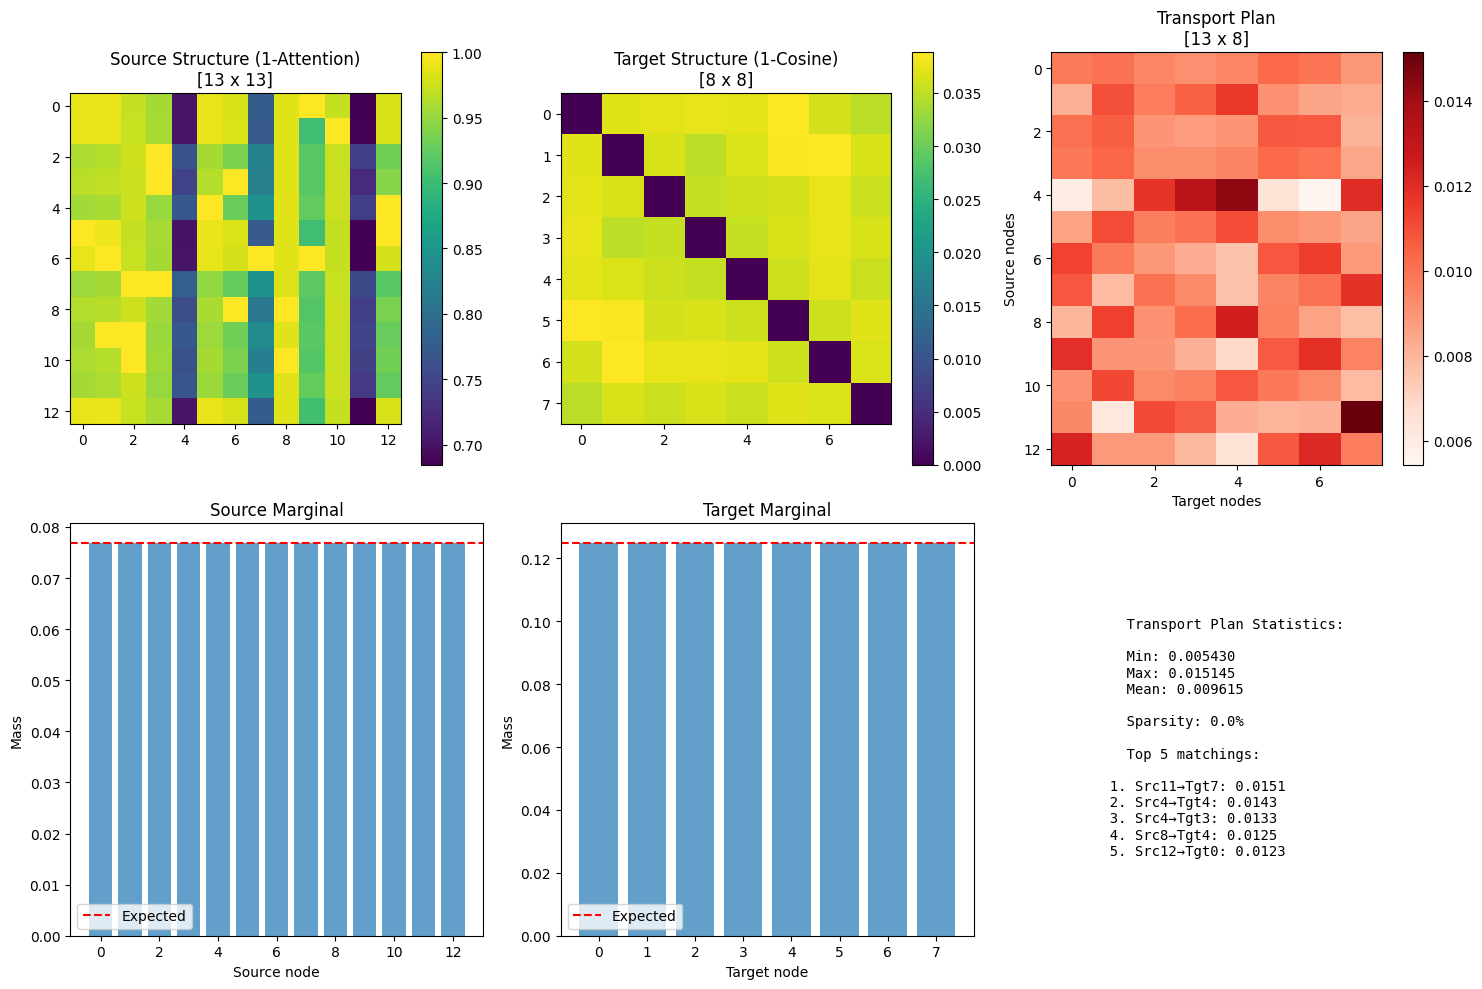

✅ Visualization saved!

Visualizing Sample 2 with Graph 2


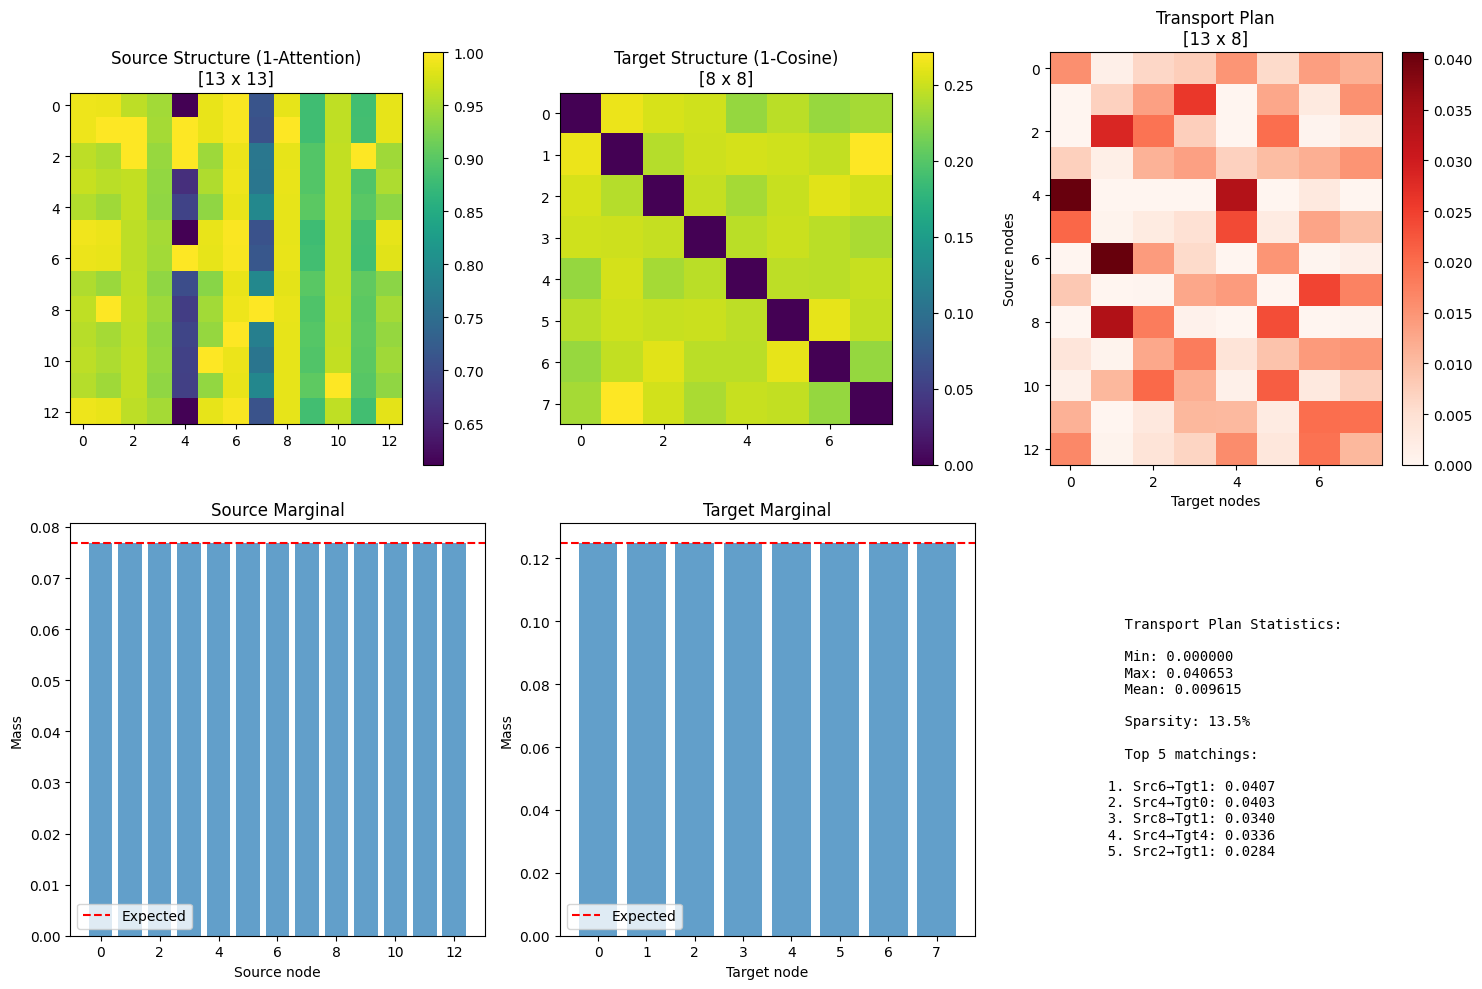

✅ Visualization saved!

Visualizing Sample 3 with Graph 3


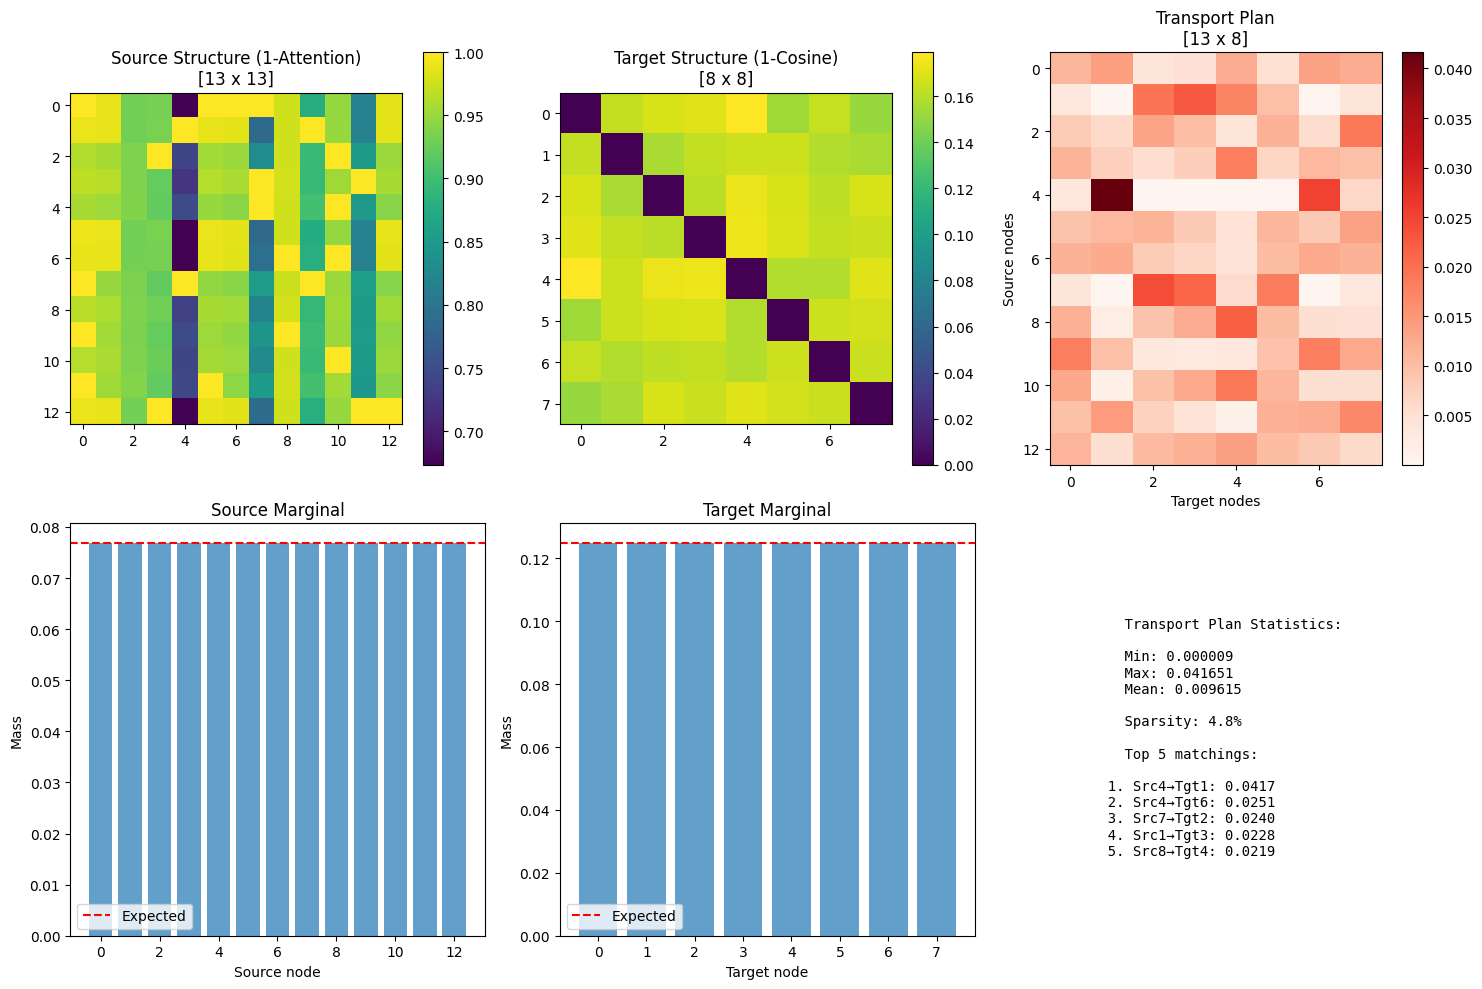

✅ Visualization saved!

Visualizing Sample 4 with Graph 4


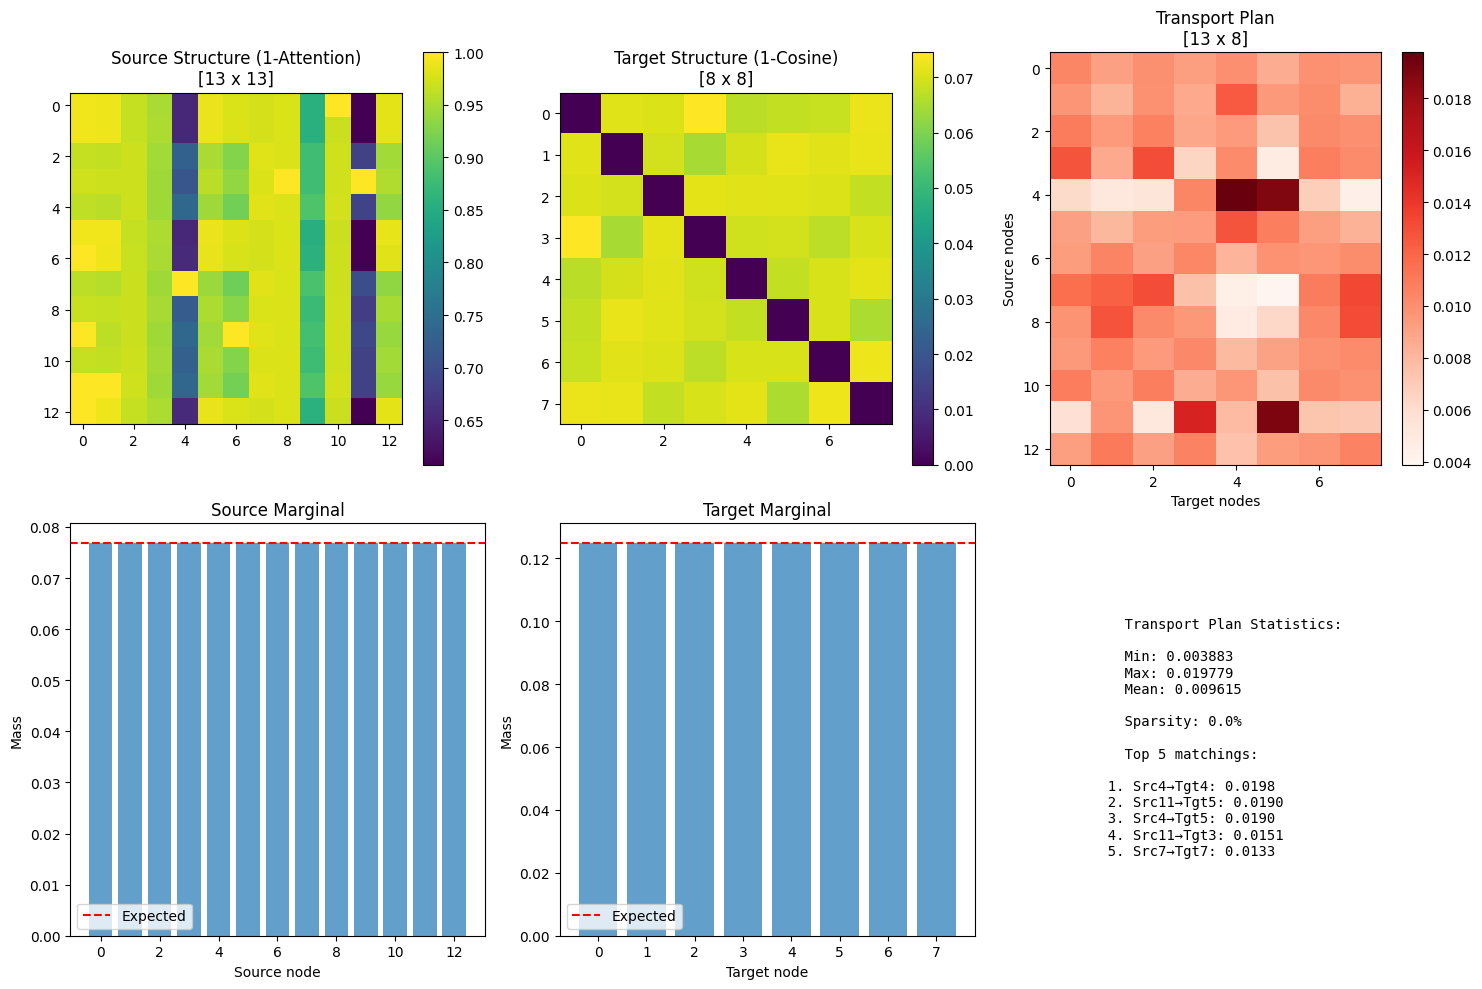

✅ Visualization saved!


In [53]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from ot.batch import solve_gromov_batch
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ========== 1. Learnable Target Graphs ==========
class LearnableGraphs(nn.Module):
    def __init__(self, M=8, K=8, D=768):
        """
        M: number of graphs
        K: number of nodes per graph
        D: dimension of node embeddings
        """
        super().__init__()
        self.M = M
        self.K = K
        self.D = D
        
        # Random initialization with different positions
        self.node_embeddings = nn.Parameter(torch.empty(M, K, D))
        sample_center = 0.07 
        for m in range(M):
            # Random direction in high-dimensional space
            direction = torch.randn(K, D)
            direction = direction / torch.norm(direction, dim=-1, keepdim=True)
            
            # Random radius (large range for diversity)
            radius = 0.5 + torch.rand(1).item() * 1.5  # [0.5, 2.0] random
            
            # Random center shift around sample mean
            sample_mean = 0.07
            center_shift = (torch.rand(1).item() - 0.5) * 0.5  # [-0.25, 0.25]
            center = sample_mean + center_shift
            
            self.node_embeddings.data[m] = direction * radius + center
    
    def compute_structure(self):
        """
        Compute structure using 1 - cosine similarity
        Returns: [M, K, K]
        """
        # Normalize embeddings
        U_norm = F.normalize(self.node_embeddings, p=2, dim=-1)  # [M, K, D]
        
        # Cosine similarity
        cosine_sim = torch.einsum("mkd,mjd->mkj", U_norm, U_norm)  # [M, K, K]
        
        # Distance = 1 - cosine similarity
        distance = 1.0 - cosine_sim
        distance = distance.clamp_min(0.0)
        
        return distance
    
    def orthogonal_loss(self):
        """
        Encourage different graphs to use different subspaces
        Returns: scalar loss
        """
        # Flatten each graph: [M, K, D] -> [M, K*D]
        flat = self.node_embeddings.view(self.M, -1)  # [M, K*D]
        
        # Normalize to unit norm (compare direction only)
        flat_norm = F.normalize(flat, p=2, dim=1)  # [M, K*D]
        
        # Compute Gram matrix (cosine similarity)
        gram = torch.matmul(flat_norm, flat_norm.T)  # [M, M] ∈ [-1, 1]
        
        # Remove diagonal (self-similarity = 1)
        gram = gram - torch.eye(self.M, device=gram.device)
        
        # Minimize off-diagonal elements (make graphs orthogonal)
        # Average over M*(M-1) off-diagonal elements
        return (gram ** 2).sum() / (self.M * (self.M - 1))
    
    def forward(self):
        """
        Returns:
            features: [M, K, D]
            structure: [M, K, K]
        """
        structure = self.compute_structure()
        return self.node_embeddings, structure


# ========== 2. Extract Source Graph from Model ==========
def extract_source_graph(model, batch):
    """
    Extract node embeddings and attention from model
    
    Returns:
        features: [B, N, D]
        structure: [B, N, N]
    """
    batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
    
    # Gather embeddings
    desc_embeddings, name_embeddings, value_embeddings = [], [], []
    if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
        desc_embeddings.append(batch['cat_desc_embeddings'])
        name_embeddings.append(batch['cat_name_embeddings'])
        value_embeddings.append(batch['cat_value_embeddings'])
    if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
        desc_embeddings.append(batch['num_desc_embeddings'])
        name_embeddings.append(batch['num_name_embeddings'])
        value_embeddings.append(batch['num_prompt_embeddings'])
    
    desc = torch.cat(desc_embeddings, dim=1)
    name = torch.cat(name_embeddings, dim=1)
    value = torch.cat(value_embeddings, dim=1)
    
    # Forward through basis layers
    x_basis = torch.cat([model.basis_cls.expand(value.size(0), 1, model.input_dim), value], dim=1)
    last_att = None
    
    for l in range(model.num_basis_layers):
        norm_x = model.basis_layer_norms[l](x_basis)
        basis_outputs, att = model.basis_layers[l](name, norm_x)
        x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)
        last_att = att
    
    # Extract without CLS
    features = x_basis[:, 1:, :]  # [B, N, D]
    
    # Attention distance (1 - attention)
    if last_att is not None:
        attention = last_att[:, :, 1:, 1:]  # [B, H, N, N]
        attention = attention.squeeze(1)     # [B, N, N] (H=1)
        structure = 1.0 - attention
        structure = structure.clamp_min(0.0)
    else:
        raise ValueError("No attention found!")
    
    return features, structure


# ========== 3. Compute FGW using POT ==========
def compute_batch_fgw(source_features, source_structure, target_features, target_structure, alpha=0.5, reg=0.01):
    """
    Compute Fused Gromov-Wasserstein distance using POT
    
    Args:
        source_features: [B, N, D_source]
        source_structure: [B, N, N]
        target_features: [M, K, D_target]
        target_structure: [M, K, K]
    
    Returns:
        result: OTResult object
    """
    B, N, D_source = source_features.shape
    M, K, D_target = target_features.shape
    
    # Expand source for all target graphs
    # [B, N, D] -> [B*M, N, D]
    source_features_exp = source_features.unsqueeze(1).expand(B, M, N, D_source).reshape(B*M, N, D_source)
    source_structure_exp = source_structure.unsqueeze(1).expand(B, M, N, N).reshape(B*M, N, N)
    
    # Expand target for all source samples
    # [M, K, D] -> [B*M, K, D]
    target_features_exp = target_features.unsqueeze(0).expand(B, M, K, D_target).reshape(B*M, K, D_target)
    target_structure_exp = target_structure.unsqueeze(0).expand(B, M, K, K).reshape(B*M, K, K)
    
    # Compute feature cost (squared Euclidean distance)
    # [B*M, N, K]
    M_cost = torch.cdist(source_features_exp, target_features_exp, p=2) ** 2
    # Normalize by dimension
    #M_cost = M_cost / D_source
    # Min-max normalize to [0, 1] for fair comparison with structure cost
    M_cost = (M_cost - M_cost.min()) / (M_cost.max() - M_cost.min() + 1e-8)
    
    # Uniform distributions
    a = torch.ones(B*M, N, device=device) / N
    b = torch.ones(B*M, K, device=device) / K
    
    # Solve FGW
    result = solve_gromov_batch(
        source_structure_exp,  # C1: [B*M, N, N]
        target_structure_exp,  # C2: [B*M, K, K]
        M=M_cost,              # Feature cost: [B*M, N, K]
        alpha=alpha,           # Balance between feature and structure
        reg=reg,               # Entropic regularization
        a=a,
        b=b,
        max_iter=50
    )
    
    # Reshape result back to [B, M]
    fgw_values = result.value.reshape(B, M)
    
    # Get feature and structure costs separately
    feature_costs = result.value_linear.reshape(B, M) if hasattr(result, 'value_linear') else None
    structure_costs = result.value_quad.reshape(B, M) if hasattr(result, 'value_quad') else None
    
    # Transport plans: [B*M, N, K] -> [B, M, N, K]
    transport_plans = result.plan.reshape(B, M, N, K)
    
    return result, fgw_values, feature_costs, structure_costs, transport_plans


# ========== 4. Main Training Loop ==========
def train_with_pot_fgw(model, dataloader, learnable_graphs, optimizer, alpha=0.5, reg=0.01):
    """
    Train using POT batch FGW
    """
    model.train()
    learnable_graphs.train()
    
    total_loss = 0.0
    num_batches = 0
    
    for batch_idx, batch in enumerate(dataloader):
        # Extract source graph from model
        source_features, source_structure = extract_source_graph(model, batch)
        
        # Get target graphs
        target_features, target_structure = learnable_graphs()
        
        # Compute FGW
        result, fgw_values, feature_costs, structure_costs, transport_plans = compute_batch_fgw(
            source_features, source_structure,
            target_features, target_structure,
            alpha=alpha, reg=reg
        )
        
        # Loss: mean FGW distance + orthogonal regularization
        
        fgw_loss = fgw_values.mean()
        orth_loss = learnable_graphs.orthogonal_loss()
        
        loss = fgw_loss + 0.1 * orth_loss  # Lambda = 0.1
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
        
        if batch_idx % 10 == 0:
            print(f"Batch {batch_idx}, Loss: {loss.item():.4f} (FGW: {fgw_loss.item():.4f}, Orth: {orth_loss.item():.4f})")
            print(f"  Total FGW (first sample): {fgw_values[0].detach().cpu().numpy()}")
            
            if feature_costs is not None:
                print(f"  Feature cost (first sample): {feature_costs[0].detach().cpu().numpy()}")
            if structure_costs is not None:
                print(f"  Structure cost (first sample): {structure_costs[0].detach().cpu().numpy()}")
    
    avg_loss = total_loss / num_batches
    return avg_loss, transport_plans


# ========== 5. Visualization ==========
def visualize_transport_plan(source_features, target_features, transport_plans, 
                            source_structure, target_structure, 
                            sample_idx=0, graph_idx=0):
    """
    Visualize transport plan for one sample and one graph
    """
    import matplotlib.pyplot as plt
    
    # Extract for visualization
    T = transport_plans[sample_idx, graph_idx].detach().cpu().numpy()  # [N, K]
    source_struct = source_structure[sample_idx].detach().cpu().numpy()  # [N, N]
    target_struct = target_structure[graph_idx].detach().cpu().numpy()  # [K, K]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # 1. Source structure
    ax = axes[0, 0]
    im = ax.imshow(source_struct, cmap='viridis')
    ax.set_title(f'Source Structure (1-Attention)\n[{source_struct.shape[0]} x {source_struct.shape[0]}]')
    plt.colorbar(im, ax=ax)
    
    # 2. Target structure
    ax = axes[0, 1]
    im = ax.imshow(target_struct, cmap='viridis')
    ax.set_title(f'Target Structure (1-Cosine)\n[{target_struct.shape[0]} x {target_struct.shape[0]}]')
    plt.colorbar(im, ax=ax)
    
    # 3. Transport Plan
    ax = axes[0, 2]
    im = ax.imshow(T, cmap='Reds', aspect='auto')
    ax.set_title(f'Transport Plan\n[{T.shape[0]} x {T.shape[1]}]')
    ax.set_xlabel('Target nodes')
    ax.set_ylabel('Source nodes')
    plt.colorbar(im, ax=ax)
    
    # 4. Source marginal
    ax = axes[1, 0]
    source_marginal = T.sum(axis=1)
    ax.bar(range(len(source_marginal)), source_marginal, alpha=0.7)
    ax.axhline(1/len(source_marginal), color='r', linestyle='--', label='Expected')
    ax.set_title('Source Marginal')
    ax.set_xlabel('Source node')
    ax.set_ylabel('Mass')
    ax.legend()
    
    # 5. Target marginal
    ax = axes[1, 1]
    target_marginal = T.sum(axis=0)
    ax.bar(range(len(target_marginal)), target_marginal, alpha=0.7)
    ax.axhline(1/len(target_marginal), color='r', linestyle='--', label='Expected')
    ax.set_title('Target Marginal')
    ax.set_xlabel('Target node')
    ax.set_ylabel('Mass')
    ax.legend()
    
    # 6. Transport plan statistics
    ax = axes[1, 2]
    ax.axis('off')
    stats_text = f"""
    Transport Plan Statistics:
    
    Min: {T.min():.6f}
    Max: {T.max():.6f}
    Mean: {T.mean():.6f}
    
    Sparsity: {(T < 1e-4).sum() / T.size * 100:.1f}%
    
    Top 5 matchings:
    """
    
    # Find top matchings
    flat_idx = np.argsort(T.flatten())[-5:][::-1]
    for rank, flat_i in enumerate(flat_idx, 1):
        i, j = np.unravel_index(flat_i, T.shape)
        stats_text += f"\n  {rank}. Src{i}→Tgt{j}: {T[i,j]:.4f}"
    
    ax.text(0.1, 0.5, stats_text, fontsize=10, family='monospace', 
            verticalalignment='center')
    
    plt.tight_layout()
    
    plt.show()
    
    print(f"✅ Visualization saved!")


# ========== 6. Main Experiment ==========
if __name__ == "__main__":
    # Get D from model
    D = model.input_dim  # Assuming model is already loaded
    
    # Initialize learnable graphs
    learnable_graphs = LearnableGraphs(M=8, K=8, D=D).to(device)
    
    # Optimizer (only for learnable graphs)
    optimizer = torch.optim.Adam(learnable_graphs.parameters(), lr=1e-3)
    
    # Get first source dataloader
    first_source = list(loaders.keys())[0]
    dataloader = loaders[first_source]
    
    print(f"Training with source: {first_source}")
    print(f"Model input_dim: {D}")
    print(f"Learnable graphs: M={learnable_graphs.M}, K={learnable_graphs.K}, D={learnable_graphs.D}")
    
    # Train for a few batches
    num_batches_to_train = 50
    from itertools import islice
    
    final_transport_plans = None
    for epoch in range(1, 4):
        print(f"\n===== Epoch {epoch} =====")
        limited_loader = islice(dataloader, num_batches_to_train)
        avg_loss, transport_plans = train_with_pot_fgw(
            model, limited_loader, learnable_graphs, optimizer,
            alpha=0.5, reg=0.01
        )
        print(f"Epoch {epoch} - Average Loss: {avg_loss:.4f}")
        final_transport_plans = transport_plans
    
    print("\n✅ Training completed!")
    
    # Visualize final transport plan
    print("\n📊 Creating visualization...")
    
    # Get one batch for visualization
    dataloader_viz = iter(loaders[first_source])
    batch_viz = next(dataloader_viz)
    source_features, source_structure = extract_source_graph(model, batch_viz)
    target_features, target_structure = learnable_graphs()
    
    _, fgw_values, _, _, transport_plans_viz = compute_batch_fgw(
        source_features, source_structure,
        target_features, target_structure,
        alpha=0.5, reg=0.01
    )
    
    B = source_features.shape[0]

    num_samples_to_visualize = 5   # 원하는 만큼

    B = source_features.shape[0]
    num_samples_to_visualize = min(num_samples_to_visualize, B)

    for sample_idx in range(num_samples_to_visualize):

        # 그냥 동일 인덱스로 graph 선택 (closest 안 씀)
        graph_idx = sample_idx % target_features.shape[0]   # target_graph 개수 초과 방지

        print(f"\nVisualizing Sample {sample_idx} with Graph {graph_idx}")

        visualize_transport_plan(
            source_features, target_features, transport_plans_viz,
            source_structure, target_structure,
            sample_idx=sample_idx,
            graph_idx=graph_idx
        )

Analyzing embedding distributions...
EMBEDDING DISTRIBUTION ANALYSIS

Sample Embeddings: (650, 768)
  Mean: 0.0692
  Std:  0.5598
  Min:  -393.1307
  Max:  365.2245

LCG Embeddings: (64, 768)
  Graph 0 - Mean: 0.0334, Std: 0.0732
  Graph 1 - Mean: 0.0335, Std: 0.0734
  Graph 2 - Mean: 0.0335, Std: 0.0734
  Graph 3 - Mean: 0.0338, Std: 0.0737
  Graph 4 - Mean: 0.0338, Std: 0.0737
  Graph 5 - Mean: 0.0339, Std: 0.0737
  Graph 6 - Mean: 0.0338, Std: 0.0736
  Graph 7 - Mean: 0.0335, Std: 0.0734


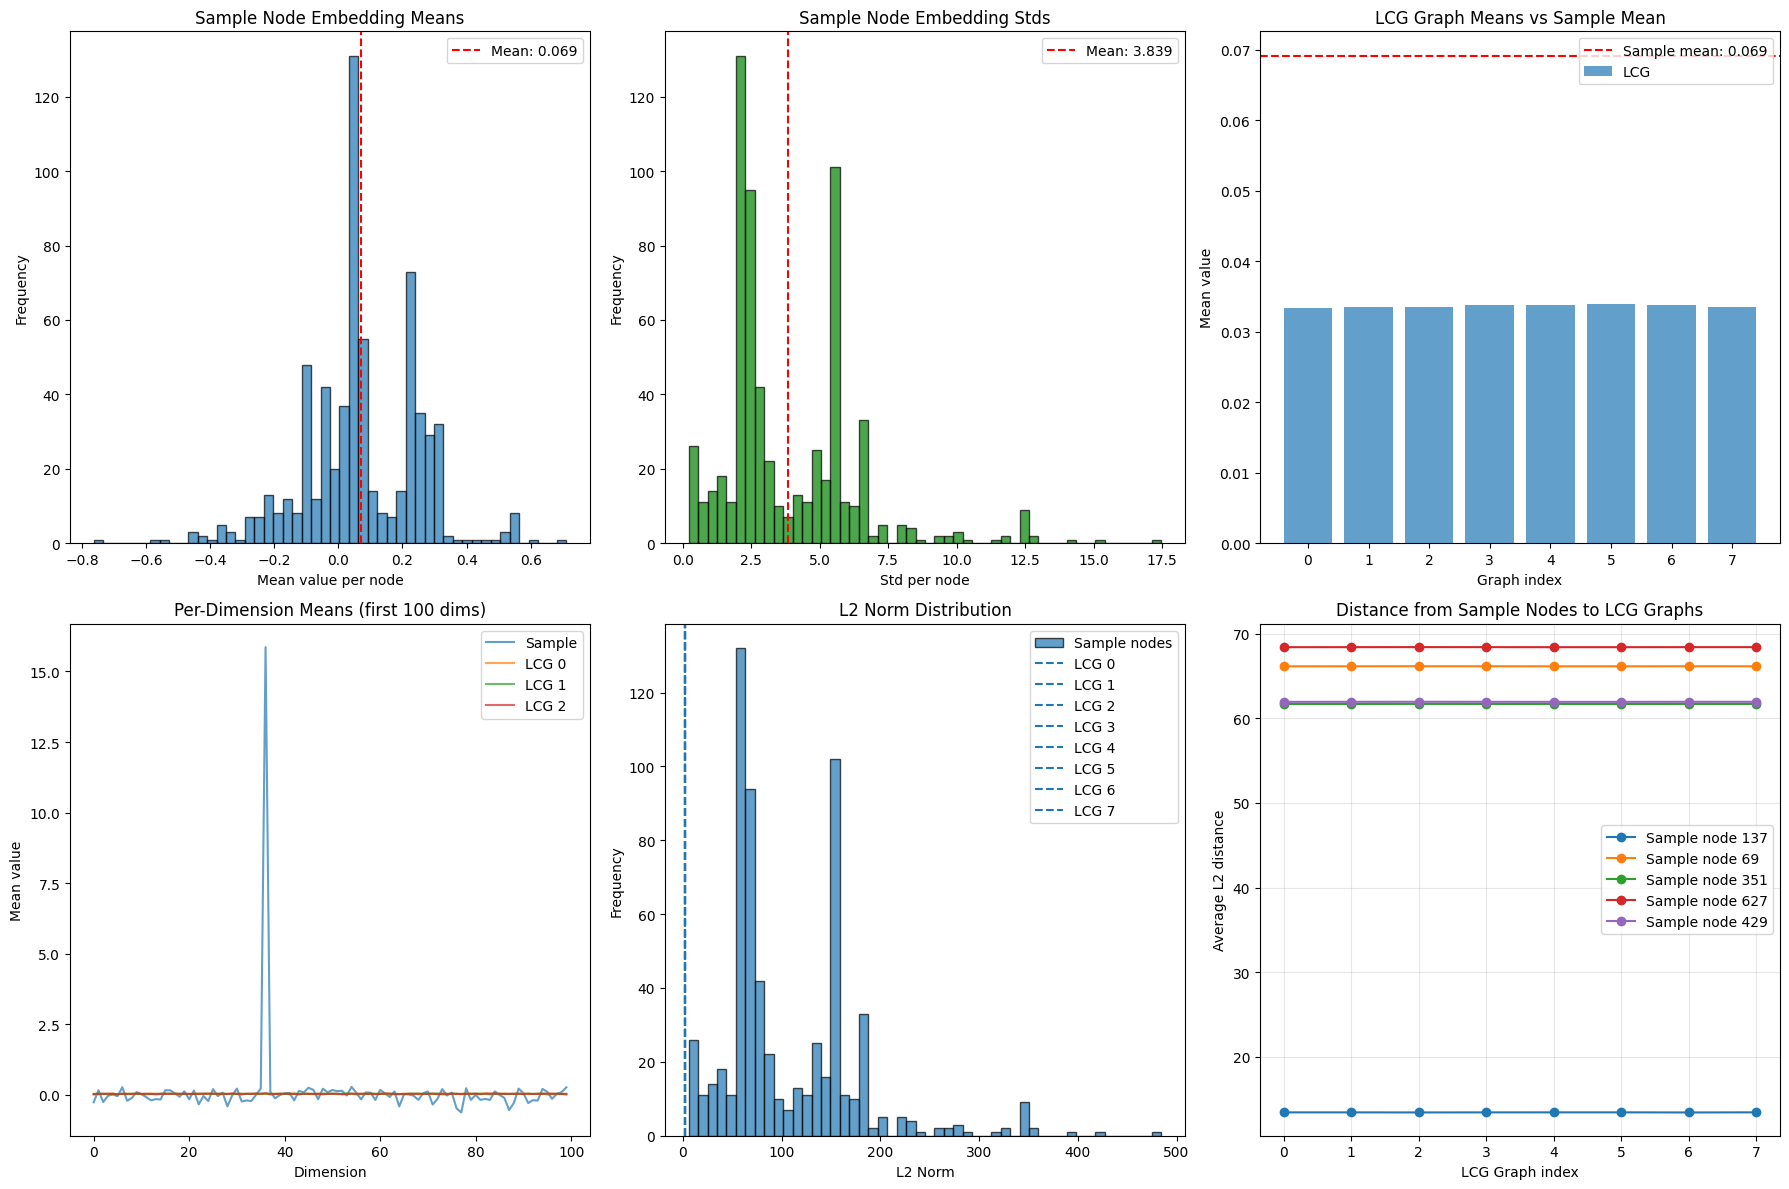


✅ Analysis complete! Plot saved.


In [34]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def analyze_embedding_distributions(model, dataloader, learnable_graphs, num_samples=100):
    """
    Analyze distribution of sample embeddings vs LCG embeddings
    """
    model.eval()
    learnable_graphs.eval()
    
    all_sample_embeddings = []
    
    # Collect sample embeddings
    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            if i >= num_samples:
                break
            
            # Extract source features
            features, _ = extract_source_graph(model, batch)
            # features: [B, N, D]
            
            # Flatten: [B, N, D] -> [B*N, D]
            features_flat = features.reshape(-1, features.shape[-1])
            all_sample_embeddings.append(features_flat)
    
    # Concatenate all
    sample_embs = torch.cat(all_sample_embeddings, dim=0).cpu().numpy()  # [Total, D]
    
    # Get LCG embeddings
    lcg_embs = learnable_graphs.node_embeddings.detach().cpu().numpy()  # [M, K, D]
    lcg_embs_flat = lcg_embs.reshape(-1, lcg_embs.shape[-1])  # [M*K, D]
    
    # Statistics
    print("=" * 60)
    print("EMBEDDING DISTRIBUTION ANALYSIS")
    print("=" * 60)
    
    print(f"\nSample Embeddings: {sample_embs.shape}")
    print(f"  Mean: {sample_embs.mean(axis=0).mean():.4f}")
    print(f"  Std:  {sample_embs.std(axis=0).mean():.4f}")
    print(f"  Min:  {sample_embs.min():.4f}")
    print(f"  Max:  {sample_embs.max():.4f}")
    
    print(f"\nLCG Embeddings: {lcg_embs_flat.shape}")
    for m in range(learnable_graphs.M):
        emb_m = lcg_embs[m].reshape(-1)
        print(f"  Graph {m} - Mean: {emb_m.mean():.4f}, Std: {emb_m.std():.4f}")
    
    # Visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Sample embedding mean distribution
    ax = axes[0, 0]
    sample_means = sample_embs.mean(axis=1)
    ax.hist(sample_means, bins=50, alpha=0.7, edgecolor='black')
    ax.axvline(sample_means.mean(), color='r', linestyle='--', 
               label=f'Mean: {sample_means.mean():.3f}')
    ax.set_title('Sample Node Embedding Means')
    ax.set_xlabel('Mean value per node')
    ax.set_ylabel('Frequency')
    ax.legend()
    
    # 2. Sample embedding std distribution
    ax = axes[0, 1]
    sample_stds = sample_embs.std(axis=1)
    ax.hist(sample_stds, bins=50, alpha=0.7, edgecolor='black', color='green')
    ax.axvline(sample_stds.mean(), color='r', linestyle='--',
               label=f'Mean: {sample_stds.mean():.3f}')
    ax.set_title('Sample Node Embedding Stds')
    ax.set_xlabel('Std per node')
    ax.set_ylabel('Frequency')
    ax.legend()
    
    # 3. Sample vs LCG mean comparison
    ax = axes[0, 2]
    lcg_means = [lcg_embs[m].mean() for m in range(learnable_graphs.M)]
    ax.bar(range(learnable_graphs.M), lcg_means, alpha=0.7, label='LCG')
    ax.axhline(sample_means.mean(), color='r', linestyle='--', 
               label=f'Sample mean: {sample_means.mean():.3f}')
    ax.set_title('LCG Graph Means vs Sample Mean')
    ax.set_xlabel('Graph index')
    ax.set_ylabel('Mean value')
    ax.legend()
    
    # 4. Per-dimension mean (first 100 dims)
    ax = axes[1, 0]
    dims_to_plot = min(100, sample_embs.shape[1])
    ax.plot(sample_embs.mean(axis=0)[:dims_to_plot], label='Sample', alpha=0.7)
    for m in range(min(3, learnable_graphs.M)):  # First 3 graphs
        ax.plot(lcg_embs[m].mean(axis=0)[:dims_to_plot], 
                label=f'LCG {m}', alpha=0.7)
    ax.set_title(f'Per-Dimension Means (first {dims_to_plot} dims)')
    ax.set_xlabel('Dimension')
    ax.set_ylabel('Mean value')
    ax.legend()
    
    # 5. Norm distribution
    ax = axes[1, 1]
    sample_norms = np.linalg.norm(sample_embs, axis=1)
    lcg_norms = [np.linalg.norm(lcg_embs[m], axis=1).mean() 
                 for m in range(learnable_graphs.M)]
    
    ax.hist(sample_norms, bins=50, alpha=0.7, label='Sample nodes', edgecolor='black')
    for m in range(learnable_graphs.M):
        ax.axvline(lcg_norms[m], linestyle='--', label=f'LCG {m}')
    ax.set_title('L2 Norm Distribution')
    ax.set_xlabel('L2 Norm')
    ax.set_ylabel('Frequency')
    ax.legend()
    
    # 6. Distance to each LCG graph
    ax = axes[1, 2]
    
    # Sample a few sample nodes
    n_samples_to_plot = min(5, sample_embs.shape[0])
    sample_indices = np.random.choice(sample_embs.shape[0], n_samples_to_plot, replace=False)
    
    distances = []
    for idx in sample_indices:
        sample_node = sample_embs[idx]
        dists = []
        for m in range(learnable_graphs.M):
            # Distance to graph m (mean distance to all nodes in graph m)
            graph_nodes = lcg_embs[m]  # [K, D]
            dist = np.mean([np.linalg.norm(sample_node - graph_nodes[k]) 
                           for k in range(learnable_graphs.K)])
            dists.append(dist)
        distances.append(dists)
    
    for i, dists in enumerate(distances):
        ax.plot(range(learnable_graphs.M), dists, marker='o', 
                label=f'Sample node {sample_indices[i]}')
    
    ax.set_title('Distance from Sample Nodes to LCG Graphs')
    ax.set_xlabel('LCG Graph index')
    ax.set_ylabel('Average L2 distance')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()

    plt.show()
    
    print("\n✅ Analysis complete! Plot saved.")
    
    return {
        'sample_embs': sample_embs,
        'lcg_embs': lcg_embs,
        'sample_means': sample_means,
        'lcg_means': lcg_means
    }


# Run analysis
if __name__ == "__main__":
    print("Analyzing embedding distributions...")
    
    # Get dataloader
    first_source = list(loaders.keys())[0]
    dataloader = loaders[first_source]
    
    results = analyze_embedding_distributions(
        model, dataloader, learnable_graphs, num_samples=50
    )